In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import glob
import os
import numpy as np
import seaborn as sns
import pandas as pd
from scipy.stats import gaussian_kde
from scipy import stats
from community import community_louvain


In [9]:
import networkx as nx

# Path to your network
file_path = "/Volumes/MZ BACKUP/data/flash_weave/WANG_ESRD_2020/random_rows/networks/30/healthy/sample_30_run_network_healthy_1.edgelist"

# Load the graph
# label='label' tells NetworkX to use the 'label' attribute in the file as the node ID
try:
    G = nx.read_edgelist(file_path,  data=[('weight', float)])
except Exception as e:
    # If the file doesn't have a 'label' attribute, load it with default IDs
    G = nx.read_edgelist(file_path)

# --- Basic Inspection ---
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

# --- Accessing Attributes ---
# Check if your FlashWeave/BEEM weights are there
for u, v, attrs in G.edges(data=True):
    print(f"Edge ({u} -> {v}) weight: {attrs.get('weight', 'No weight')}")
    break # Just to check the first one

Nodes: 26
Edges: 21
Edge (d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__Lawsonibacter -> d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__Flavonifractor) weight: 0.7309049367904663


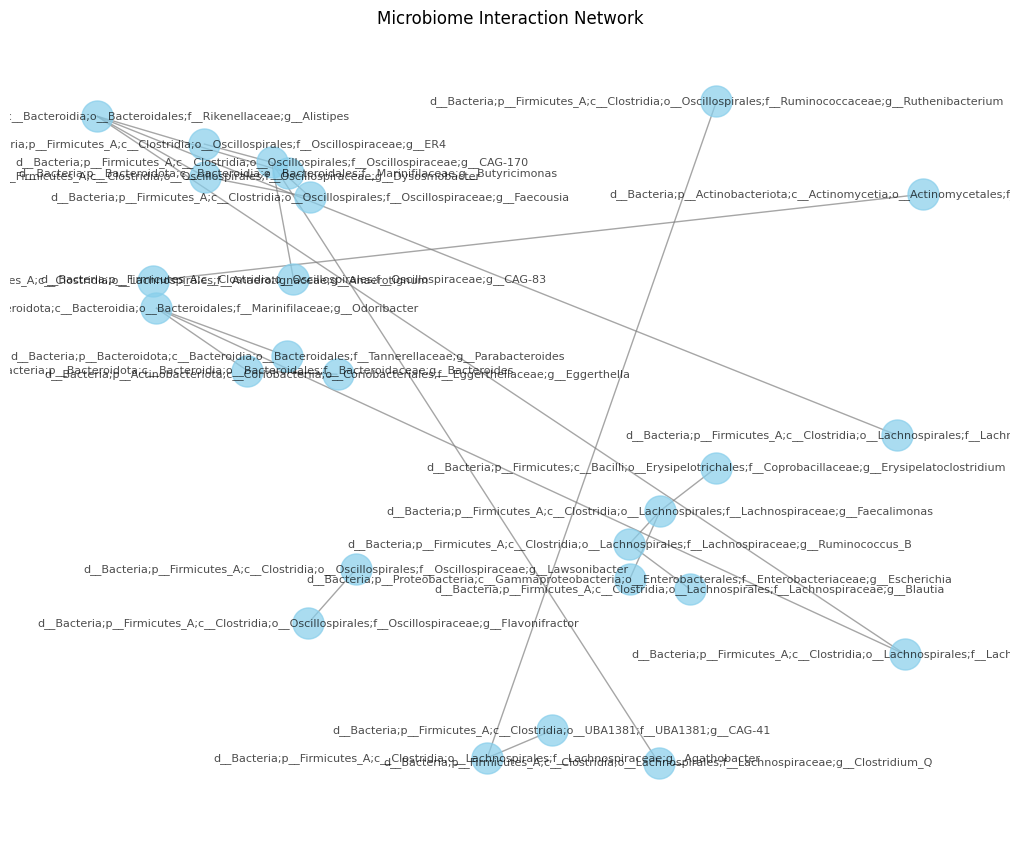

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))

# 1. Choose a layout (Spring layout is standard for microbiome networks)
pos = nx.spring_layout(G, k=0.15, iterations=20)

# 2. Draw the nodes and edges
nx.draw(G, pos, 
        with_labels=True, 
        node_color='skyblue', 
        node_size=500, 
        edge_color='gray', 
        alpha=0.7, 
        font_size=8)

plt.title("Microbiome Interaction Network")
plt.show()

In [2]:
def plot_sequential_distributions(base_path, num_bins = 10):
    """
    Loops through 30, 60, and 90.
    For each size:
    1. Shows 100 Linear Histograms.
    2. Shows 100 Log-Binned Scatter plots.
    """
    sizes = ['30', '60', '90']
    edge_schema = [('weight', float)]
    folders = ['random_columns', 'random_rows']
    healthy_or_unhealthy = ['healthy', 'unhealthy']
    for folder_type in folders:
        for size in sizes:
            for health_status in healthy_or_unhealthy:
                search_pattern = os.path.join(base_path, folder_type, 'networks', size, health_status, f"sample_{size}_run_network_{health_status}_*.edgelist")
                files = sorted(glob.glob(search_pattern))[:100]
                
                if not files:
                    print(f"No files found for Size {size} in {search_pattern}")
                    continue

                # --- PART 1: 100 LINEAR PLOTS ---
                print(f"📊 Showing 100 LINEAR plots for Size {size}...")
                fig_lin, axes_lin = plt.subplots(10, 10, figsize=(25, 25))
                axes_lin = axes_lin.flatten()

                # --- PART 2: 100 LOG-BINNED PLOTS ---
                # fig_log, axes_log = plt.subplots(10, 10, figsize=(25, 25))
                # axes_log = axes_log.flatten()

                for i, file_path in enumerate(files):
                    try:
                        G = nx.read_edgelist(file_path, data=[('weight', float)])
                        degree_sequence = [G.degree(n) for n in G.nodes() if G.degree(n) > 0]

                        run_id = os.path.basename(file_path).split('_')[-1].split('.')[0]

                        # Plot Linear
                        ax_lin = axes_lin[i]
                        ax_lin.hist(degree_sequence, bins=10, label='data')
                        ax_lin.set_xlabel('$k$',fontsize=15)  ### Set label of the axis
                        ax_lin.set_ylabel('$P(k)$',fontsize=15)

                        ax_lin.set_title(f"R{run_id}", fontsize=8)
                        ax_lin.tick_params(which='major',axis='both',labelsize=15) ### Size labels ticks
                        ax_lin.grid(False)

                        # Plot Log-Binning
                        # num_nodes = len(G.nodes())
                        # min_deg, max_deg = min(degree_sequence), max(degree_sequence)
                        
                        # bins = np.logspace(np.log10(min_deg), np.log10(max_deg), num_bins + 1)
                        
                        # counts, bin_edges = np.histogram(degree_sequence, bins=bins)
                        
                        # # Normalize
                        # bin_widths = np.diff(bin_edges)
                        # density = counts / (num_nodes * bin_widths)
                        
                        # bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

                        # idx = density > 0
                        # log_k = np.log10(bin_centers[idx])
                        # log_P = np.log10(density[idx])
                        
                        # m, b = np.polyfit(log_k, log_P, 1)
                        
                        # theoretical_P = 10**(m * np.log10(bin_centers) + b)

                        # ax_log = axes_log[i]
                        # #ax_log.grid(False)
                        # ax_log.scatter(bin_centers, density)

                        # ax_log.plot(bin_centers, theoretical_P, 'k-', label=f'$\\gamma = {-m:.2f}$')
                        
                        # # Set both axes to log scale
                        # ax_log.set_xscale('log')
                        # ax_log.set_yscale('log')
                        
                        # #ax_log.set_xlabel('$k$', fontsize=15)
                        # #ax_log.set_ylabel('$P(k)$', fontsize=15)
                        # ax_log.set_title(f"R{run_id}", fontsize=8)
                        # ax_log.grid(False)
                        # ax_log.legend()
                        

                    except Exception:
                        pass

                # Finalize and show Linear Grid
                fig_lin.suptitle(f"{folder_type.upper()} - SIZE {size} | 100 LINEAR HISTOGRAMS", fontsize=35, y=1.02)
                fig_lin.tight_layout()
                
                # Finalize and show Log Grid
                # fig_log.suptitle(f"{folder_type.upper()} - SIZE {size} | 100 LOG-BINNED PLOTS", fontsize=35, y=1.02)
                # fig_log.tight_layout()

                # Trigger the display for both
                
                plt.show()

In [3]:
def run_full_clustering_suite(base_path):
    """
    Automatically crawls:
    - random_rows & random_columns
    - 30, 60, and 90 sizes
    Displays a distribution plot for the 100 runs in each category.
    """
    folder_types = ["random_rows", "random_columns"]
    sizes = ["30", "60", "90"]
    edge_schema = [('weight', float)]
    healthy_or_unhealthy = ['healthy', 'unhealthy']

    # Set the visual style
    sns.set_theme(style="whitegrid")
    
    for f_type in folder_types:
        for health_status in healthy_or_unhealthy:
            # Create a figure for each folder type (Rows or Columns)
            # This will contain 3 subplots (one for 30, 60, 90)
            fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
            
            print(f"📂 Processing Category: {f_type.upper()}")


            for i, size in enumerate(sizes):
                search_pattern = os.path.join(base_path, f_type, 'networks', size,  health_status, f"sample_{size}_run_network_{health_status}_*.edgelist")
                files = sorted(glob.glob(search_pattern))[:100]
                
                if not files:
                    print(f"   ⚠️ No files for {size} in {f_type}")
                    continue

                # Calculate average clustering for all 100 samples
                clustering_results = []
                for f in files:
                    try:

                        G = nx.read_edgelist(f, data=[('weight', float)])
                        clustering_results.append(nx.average_clustering(G))
                    except Exception:
                        continue

                # --- Plotting the Distribution ---
                ax = axes[i]
                if clustering_results:
                    # 1. Density Curve
                    sns.kdeplot(clustering_results, ax=ax, fill=True, color="teal", alpha=0.4)
                    # 2. Rug plot (marks each of the 100 runs individually)
                    sns.rugplot(clustering_results, ax=ax, color="darkslategrey", alpha=0.5)
                    
                    # Stats for the title
                    avg = np.mean(clustering_results)
                    std = np.std(clustering_results)
                    ax.set_title(f"Size {size}\nAvg: {avg:.3f} (±{std:.3f})", fontsize=14)
                
                ax.set_xlabel("Average Clustering Coefficient")
                if i == 0:
                    ax.set_ylabel("Density of Runs")

            fig.suptitle(f"Clustering Stability Across 100 Runs: {f_type.replace('_', ' ').title()} - health_status={health_status.upper()}", 
                        fontsize=20, y=1.05)
            plt.tight_layout()
            plt.show()

In [4]:
def plot_degree_average(base_path):
    """
    Automatically crawls:
    - random_rows & random_columns
    - 30, 60, and 90 sizes
    Displays a distribution plot for the 100 runs in each category.
    """
    folder_types = ["random_rows", "random_columns"]
    sizes = ["30", "60", "90"]
    healthy_or_unhealthy = ['healthy', 'unhealthy']

    # Set the visual style
    sns.set_theme(style="whitegrid")
    
    for f_type in folder_types:
        for health_status in healthy_or_unhealthy:
            
			# Create a figure for each folder type (Rows or Columns)
			# This will contain 3 subplots (one for 30, 60, 90)
            fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
			
            print(f"📂 Processing Category: {f_type.upper()}")

            for i, size in enumerate(sizes):
                search_pattern = os.path.join(base_path, f_type, 'networks', size, health_status, f"sample_{size}_run_network_{health_status}_*.edgelist")
                files = sorted(glob.glob(search_pattern))[:100]
                
                if not files:
                    print(f"   ⚠️ No files for {size} in {f_type}")
                    continue

                # Calculate average clustering for all 100 samples
                degree_results = []
                for f in files:
                    try:
                        G = nx.read_edgelist(f, data=[('weight', float)])
                        degrees = [d for _, d in G.degree()]
                        degree_results.append(sum(degrees) / len(degrees))
                    except Exception:
                        continue

                # --- Plotting the Distribution ---
                ax = axes[i]
                if degree_results:
                    # 1. Density Curve
                    sns.kdeplot(degree_results, ax=ax, fill=True, color="teal", alpha=0.4)
                    # 2. Rug plot (marks each of åthe 100 runs individually)
                    sns.rugplot(degree_results, ax=ax, color="darkslategrey", alpha=0.5)
                    
                    # Stats for the title
                    avg = np.mean(degree_results)
                    std = np.std(degree_results)
                    ax.set_title(f"Size {size}\nAvg: {avg:.3f} (±{std:.3f})", fontsize=14)
                
                ax.set_xlabel("Average Degree")
                if i == 0:
                    ax.set_ylabel("Density of Runs")

            fig.suptitle(f"Degree Distribution Across 100 Runs: {f_type.replace('_', ' ').title()}", 
                        fontsize=20, y=1.05)
            plt.tight_layout()
            plt.show()

In [5]:

def save_results_to_tsv(dataset, rows_or_cols, healthy_or_unhealthy):
	percentages = [30, 60, 90]
	num_iterations = 100

	results = []

	if rows_or_cols == 'rows':
		random_type = 'random_rows'
	elif rows_or_cols == 'columns':
		random_type = 'random_columns'

	for p in percentages:
		print(f"Processing {p}% subsets...")

		for i in range(1, num_iterations + 1):
			# Updated extension to .graphml
			filename = f"sample_{p}_run_network_{healthy_or_unhealthy}_{i}.edgelist"
			path = f"{dataset}/{random_type}/networks/{p}/{healthy_or_unhealthy}/{filename}"

			if not os.path.isfile(path):
				continue

			print(f"Reading: {filename}")

			try:
				# 1. Load the GraphML file using NetworkX
				G = nx.read_edgelist(path, data=[('I', float)])

				# Use the attribute 'I' because 'Strength' is absolute/positive only
				weights = [data.get('I', 0) for u, v, data in G.edges(data=True)]

				w_series = pd.Series(weights)
				# Calculation logic
				sum_pos = w_series[w_series > 0].sum()
				sum_neg = w_series[w_series < 0].abs().sum()

				total_weight = sum_pos + sum_neg
				if total_weight == 0:
					rho_inferred = 0
				else:
					rho_inferred = (sum_pos - sum_neg) / total_weight

				results.append((p, i, rho_inferred))

			except Exception as e:
				print(f"Error reading {filename}: {e}")

	# Save results
	all_results = pd.DataFrame(results, columns=["Percentage", "Iteration", "Rho"])
	os.makedirs('results', exist_ok=True) # Ensure directory exists
	all_results.to_csv(f'results/df_{healthy_or_unhealthy}_30_60_90_{dataset}_{rows_or_cols}.tsv', sep='\t', index=False)

In [6]:
save_results_to_tsv('iHMP_IBDMDB_2019', 'rows', 'unhealthy')
save_results_to_tsv('iHMP_IBDMDB_2019', 'rows', 'healthy')
save_results_to_tsv('YACHIDA_CRC_2019', 'rows', 'unhealthy')
save_results_to_tsv('YACHIDA_CRC_2019', 'rows', 'healthy')
save_results_to_tsv('WANG_ESRD_2020', 'rows', 'unhealthy')
save_results_to_tsv('WANG_ESRD_2020', 'rows', 'healthy')

Processing 30% subsets...
Reading: sample_30_run_network_unhealthy_1.edgelist
Reading: sample_30_run_network_unhealthy_2.edgelist
Reading: sample_30_run_network_unhealthy_3.edgelist
Reading: sample_30_run_network_unhealthy_4.edgelist
Reading: sample_30_run_network_unhealthy_5.edgelist
Reading: sample_30_run_network_unhealthy_6.edgelist
Reading: sample_30_run_network_unhealthy_7.edgelist
Reading: sample_30_run_network_unhealthy_8.edgelist
Reading: sample_30_run_network_unhealthy_9.edgelist
Reading: sample_30_run_network_unhealthy_10.edgelist
Reading: sample_30_run_network_unhealthy_11.edgelist
Reading: sample_30_run_network_unhealthy_12.edgelist
Reading: sample_30_run_network_unhealthy_13.edgelist
Reading: sample_30_run_network_unhealthy_14.edgelist
Reading: sample_30_run_network_unhealthy_15.edgelist
Reading: sample_30_run_network_unhealthy_16.edgelist
Reading: sample_30_run_network_unhealthy_17.edgelist
Reading: sample_30_run_network_unhealthy_18.edgelist
Reading: sample_30_run_networ

In [7]:
save_results_to_tsv('iHMP_IBDMDB_2019', 'columns', 'unhealthy')
save_results_to_tsv('iHMP_IBDMDB_2019', 'columns', 'healthy')
save_results_to_tsv('YACHIDA_CRC_2019', 'columns', 'unhealthy')
save_results_to_tsv('YACHIDA_CRC_2019', 'columns', 'healthy')
save_results_to_tsv('WANG_ESRD_2020', 'columns', 'unhealthy')
save_results_to_tsv('WANG_ESRD_2020', 'columns', 'healthy')

Processing 30% subsets...
Reading: sample_30_run_network_unhealthy_1.edgelist
Reading: sample_30_run_network_unhealthy_2.edgelist
Reading: sample_30_run_network_unhealthy_3.edgelist
Reading: sample_30_run_network_unhealthy_4.edgelist
Reading: sample_30_run_network_unhealthy_5.edgelist
Reading: sample_30_run_network_unhealthy_6.edgelist
Reading: sample_30_run_network_unhealthy_7.edgelist
Reading: sample_30_run_network_unhealthy_8.edgelist
Reading: sample_30_run_network_unhealthy_9.edgelist
Reading: sample_30_run_network_unhealthy_10.edgelist
Reading: sample_30_run_network_unhealthy_11.edgelist
Reading: sample_30_run_network_unhealthy_12.edgelist
Reading: sample_30_run_network_unhealthy_13.edgelist
Reading: sample_30_run_network_unhealthy_14.edgelist
Reading: sample_30_run_network_unhealthy_15.edgelist
Reading: sample_30_run_network_unhealthy_16.edgelist
Reading: sample_30_run_network_unhealthy_17.edgelist
Reading: sample_30_run_network_unhealthy_18.edgelist
Reading: sample_30_run_networ

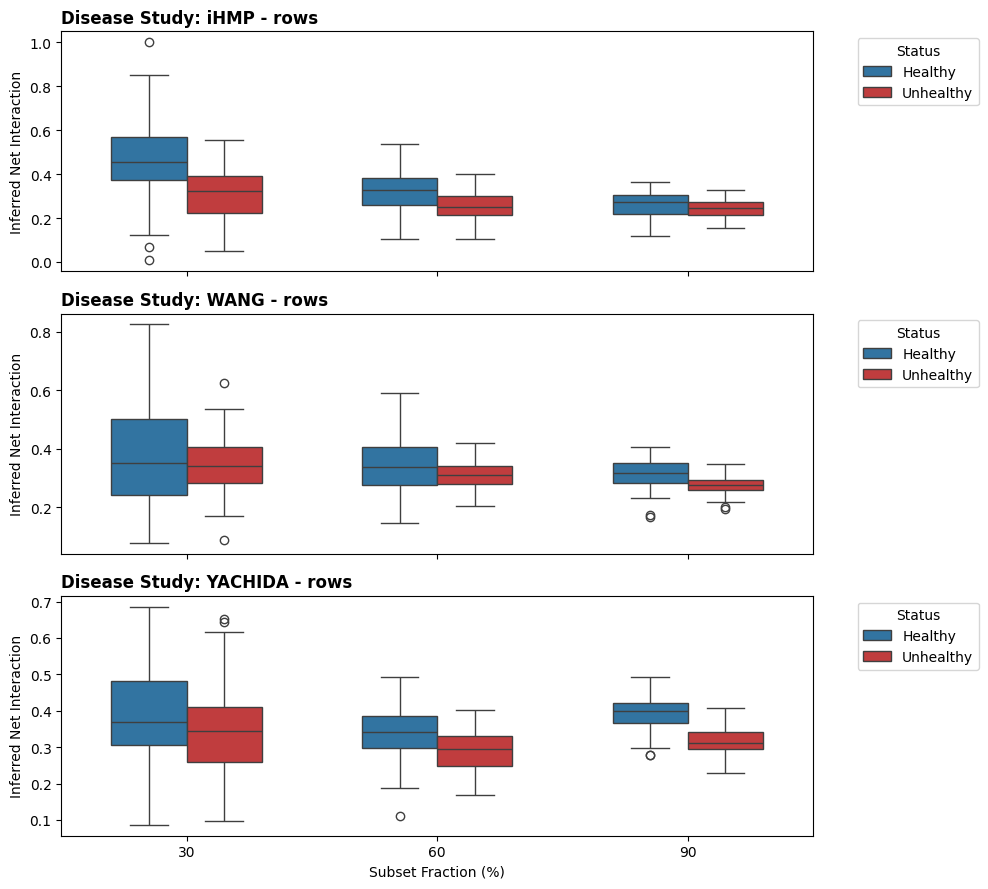

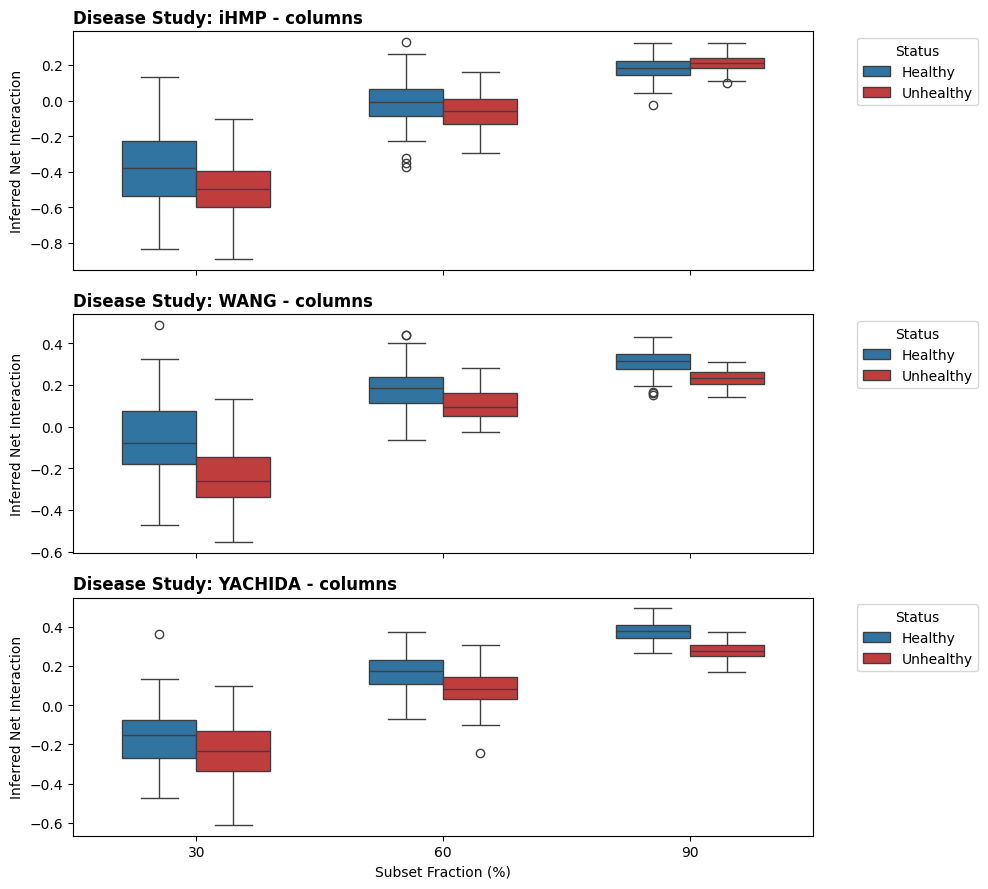

In [8]:
# 1. Load and Preprocess Data
all_data = []

# Update this path to where your files are stored
file_list = glob.glob("results/*.tsv")

for file_path in file_list:
    filename = os.path.basename(file_path)
    parts = filename.split('_')
    
    # Extract metadata from filename
    # Example: df_healthy_30_60_90_YACHIDA_CRC_2019_rows.tsv
    status = parts[1]      # healthy / unhealthy
    dimension = parts[-1].replace('.tsv', '') # rows / columns
    disease = parts[5]     # e.g., YACHIDA, iHMP, WANG
    
    df = pd.read_csv(file_path, sep='\t')
    df['Status'] = status.capitalize()
    df['Disease'] = disease
    df['Dimension'] = dimension
    all_data.append(df)

master_df = pd.concat(all_data, ignore_index=True)

# 2. Plotting Function
def plot_dimension(df, dim_name):
    subset = df[df['Dimension'] == dim_name]
    diseases = subset['Disease'].unique()
    
    fig, axes = plt.subplots(len(diseases), 1, figsize=(10, 3 * len(diseases)), sharex=True)
    
    # If only one disease, axes isn't a list
    if len(diseases) == 1: axes = [axes]
    
    for i, disease in enumerate(diseases):
        data_plot = subset[subset['Disease'] == disease]
        
        sns.boxplot(
            data=data_plot, 
            x='Percentage', 
            y='Rho', 
            hue='Status',
            ax=axes[i],
            palette={'Healthy': '#1f77b4', 'Unhealthy': '#d62728'},
            width=0.6
        )
        
        axes[i].set_title(f"Disease Study: {disease} - {dim_name}", loc='left', fontweight='bold')
        axes[i].set_ylabel("Inferred Net Interaction")
        axes[i].legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
        
    plt.xlabel("Subset Fraction (%)")
    plt.tight_layout()
    plt.savefig(f"plot_{dim_name}.png", dpi=300)
    plt.show()

# 3. Execute
plot_dimension(master_df, 'rows')
plot_dimension(master_df, 'columns')

📊 Showing 100 LINEAR plots for Size 30...


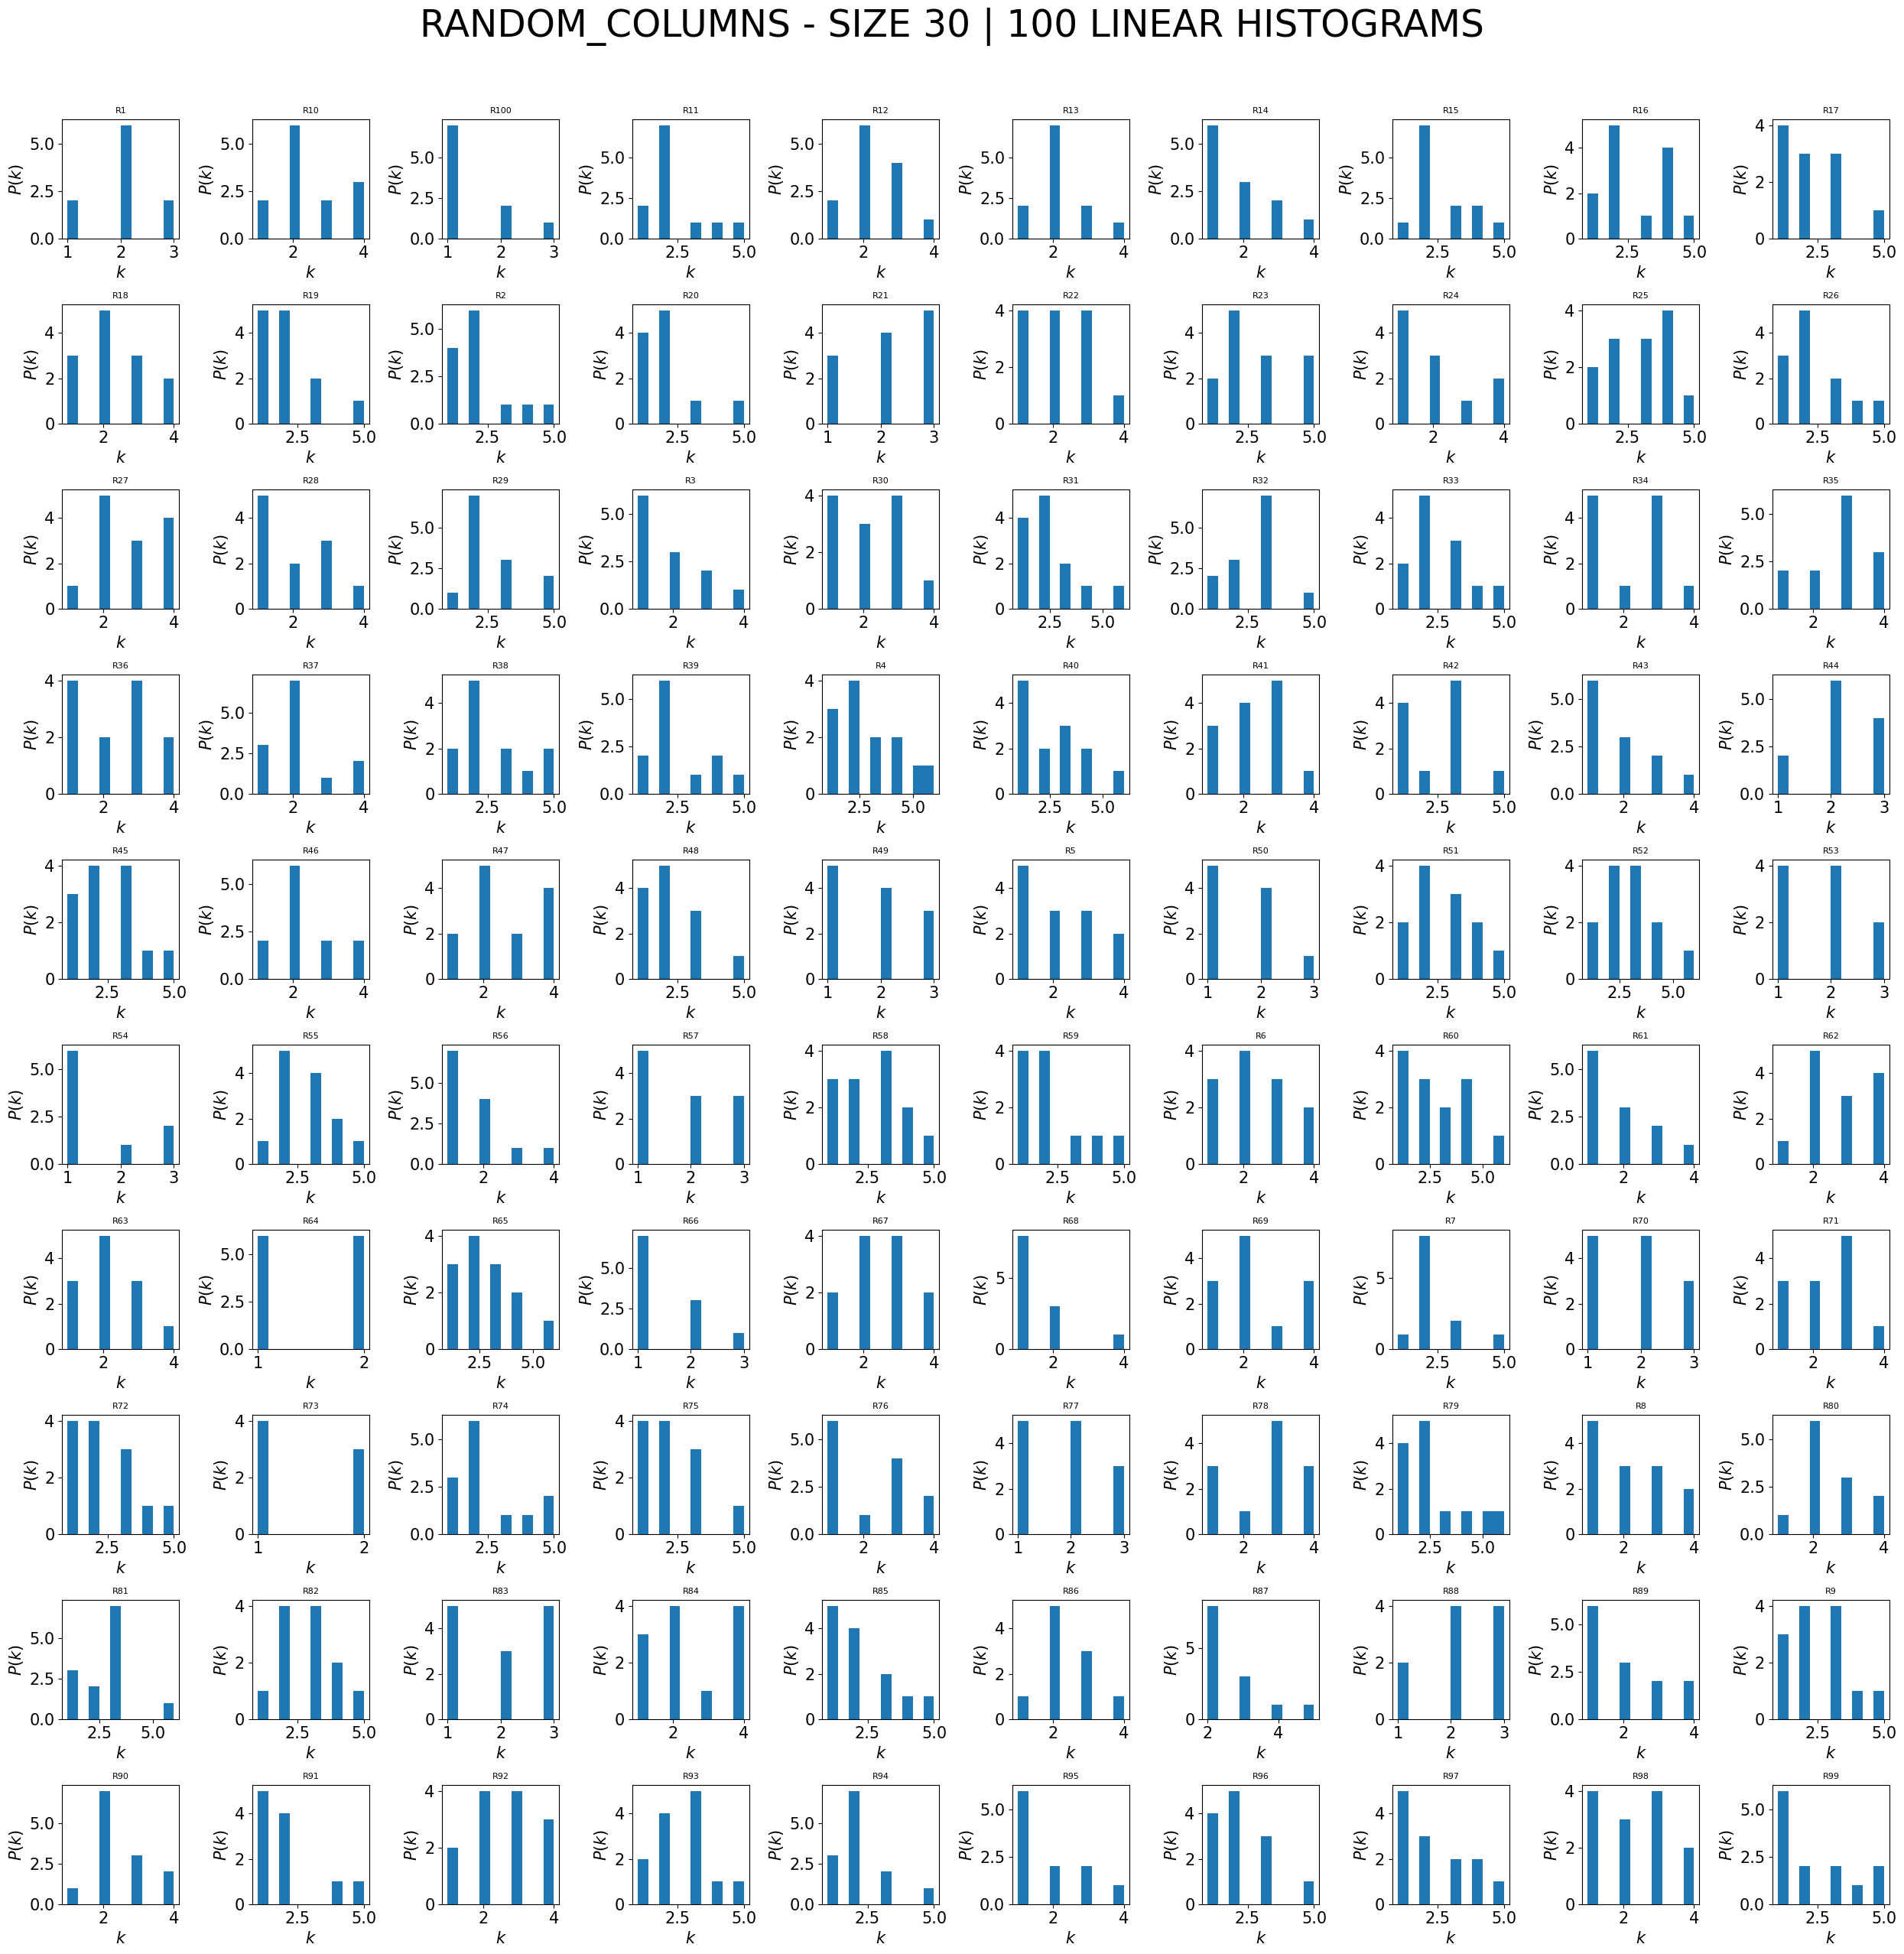

📊 Showing 100 LINEAR plots for Size 30...


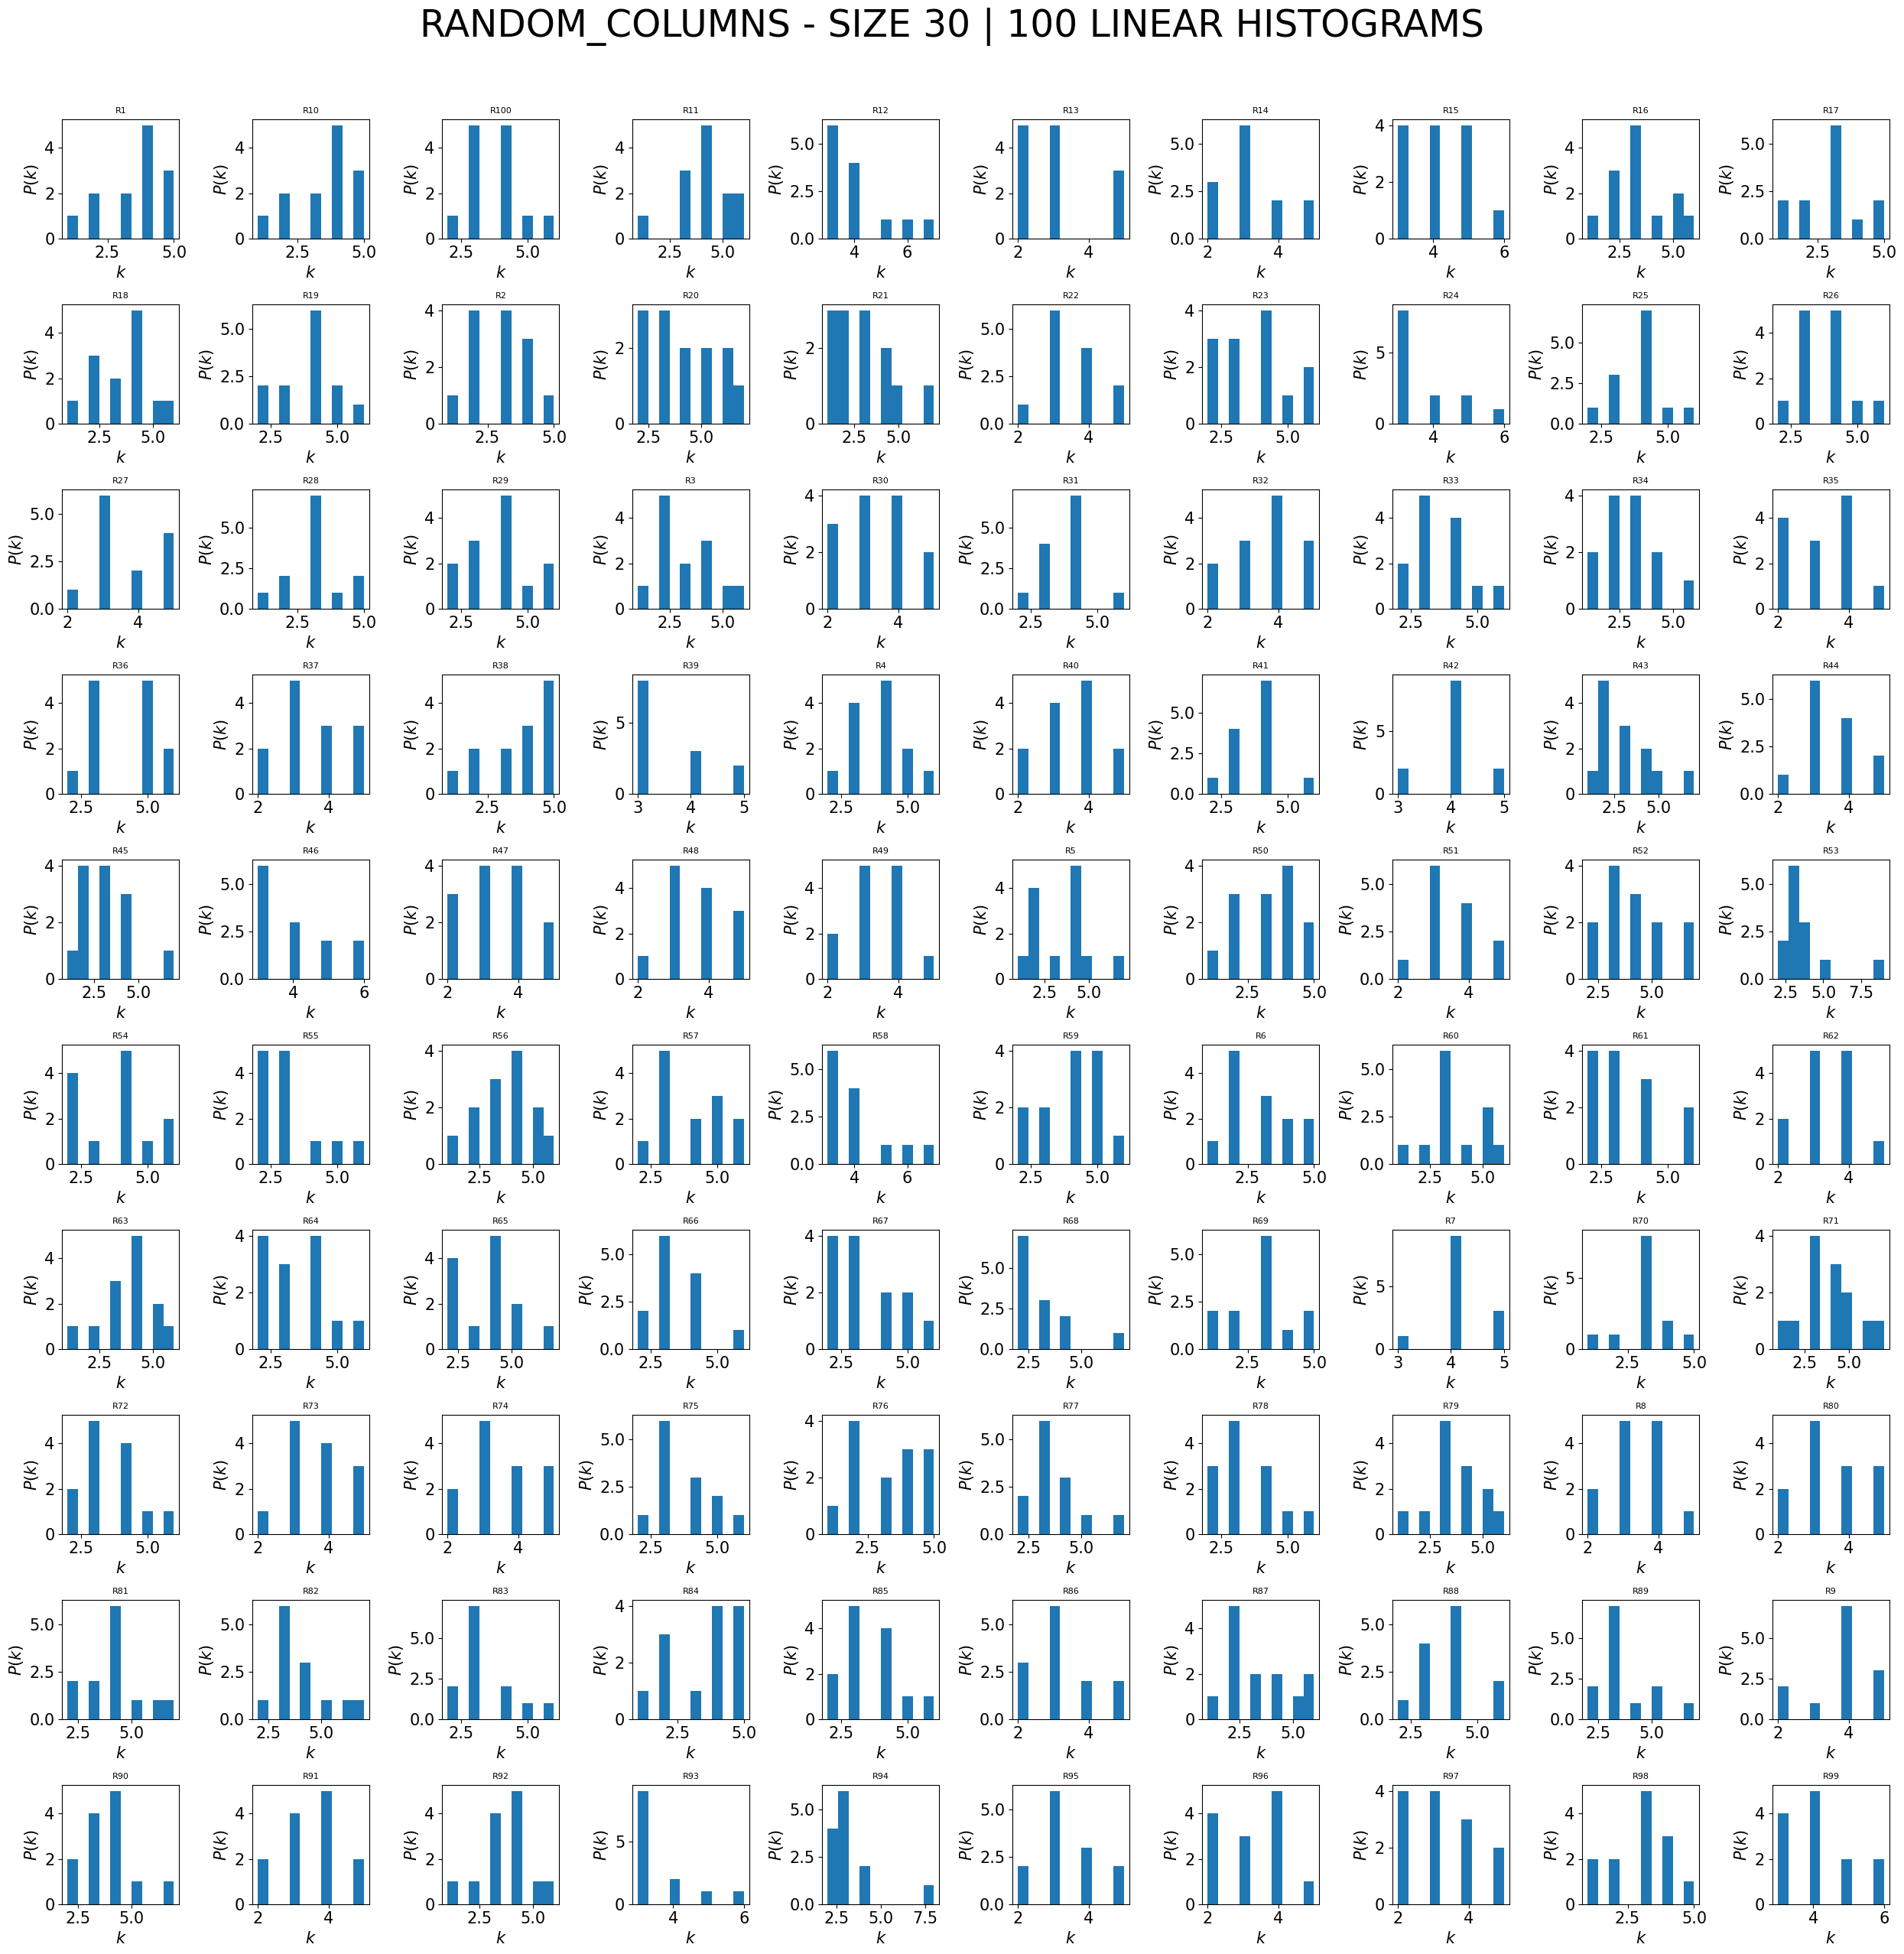

📊 Showing 100 LINEAR plots for Size 60...


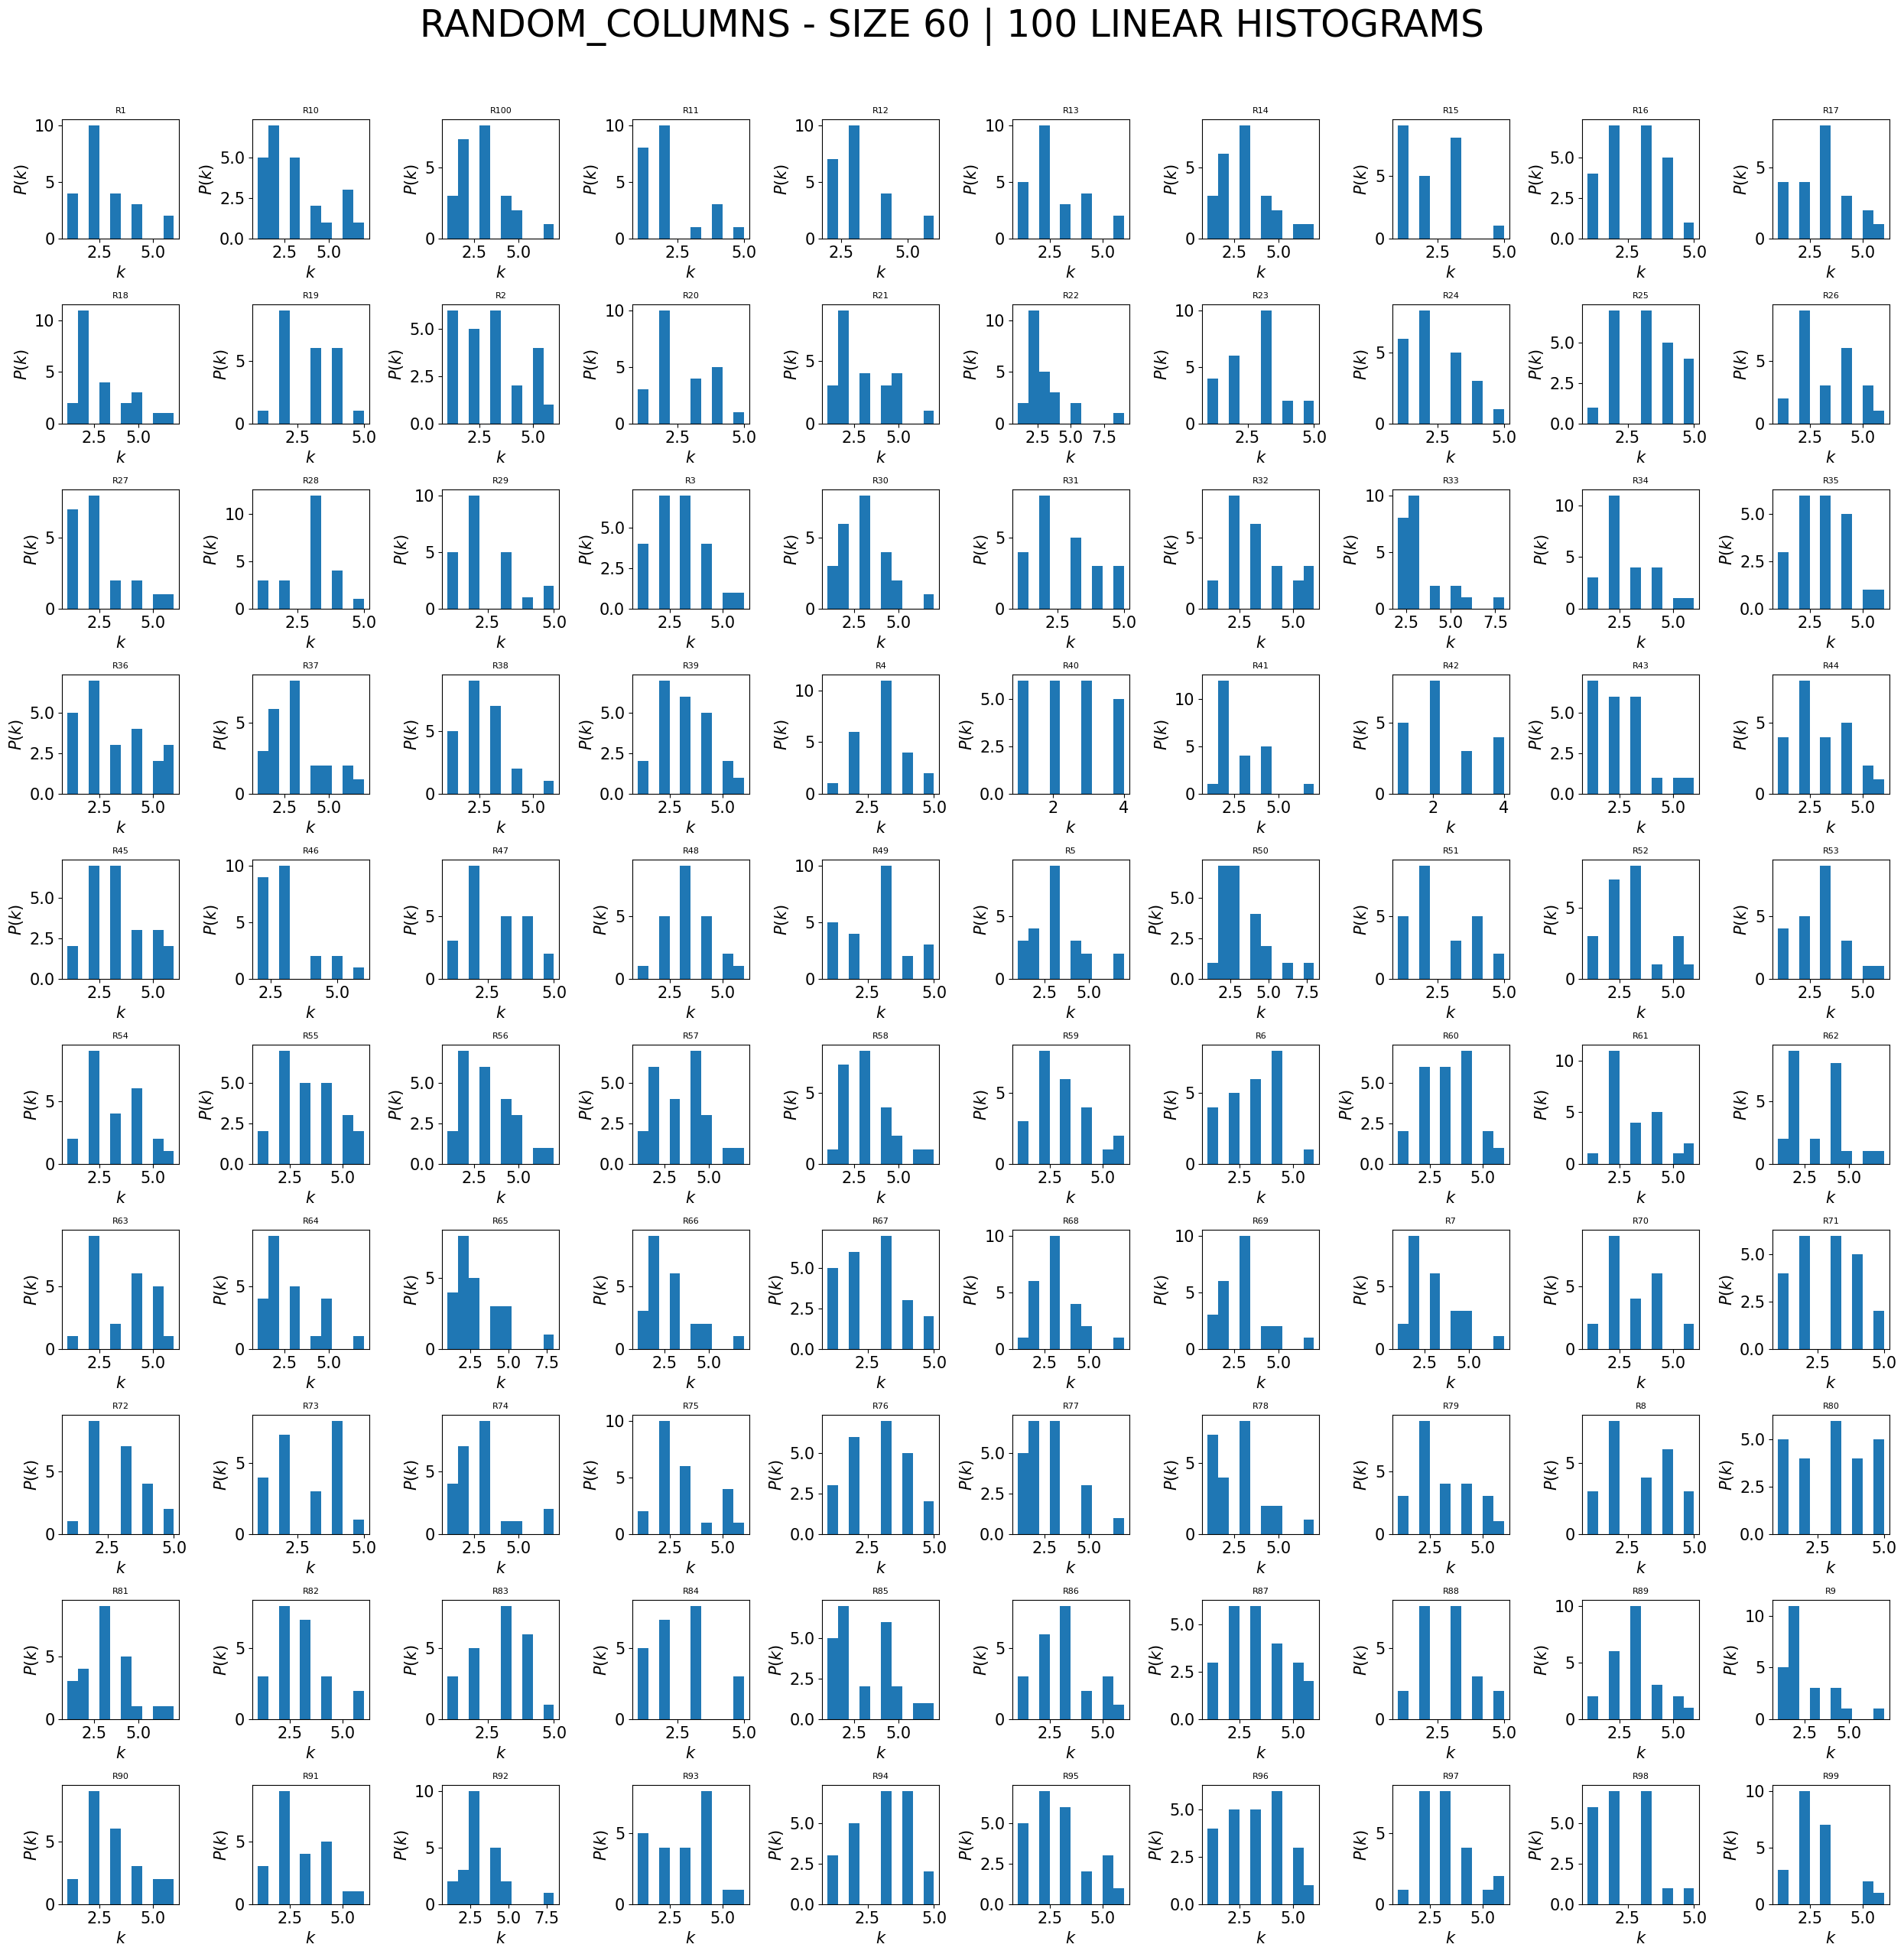

📊 Showing 100 LINEAR plots for Size 60...


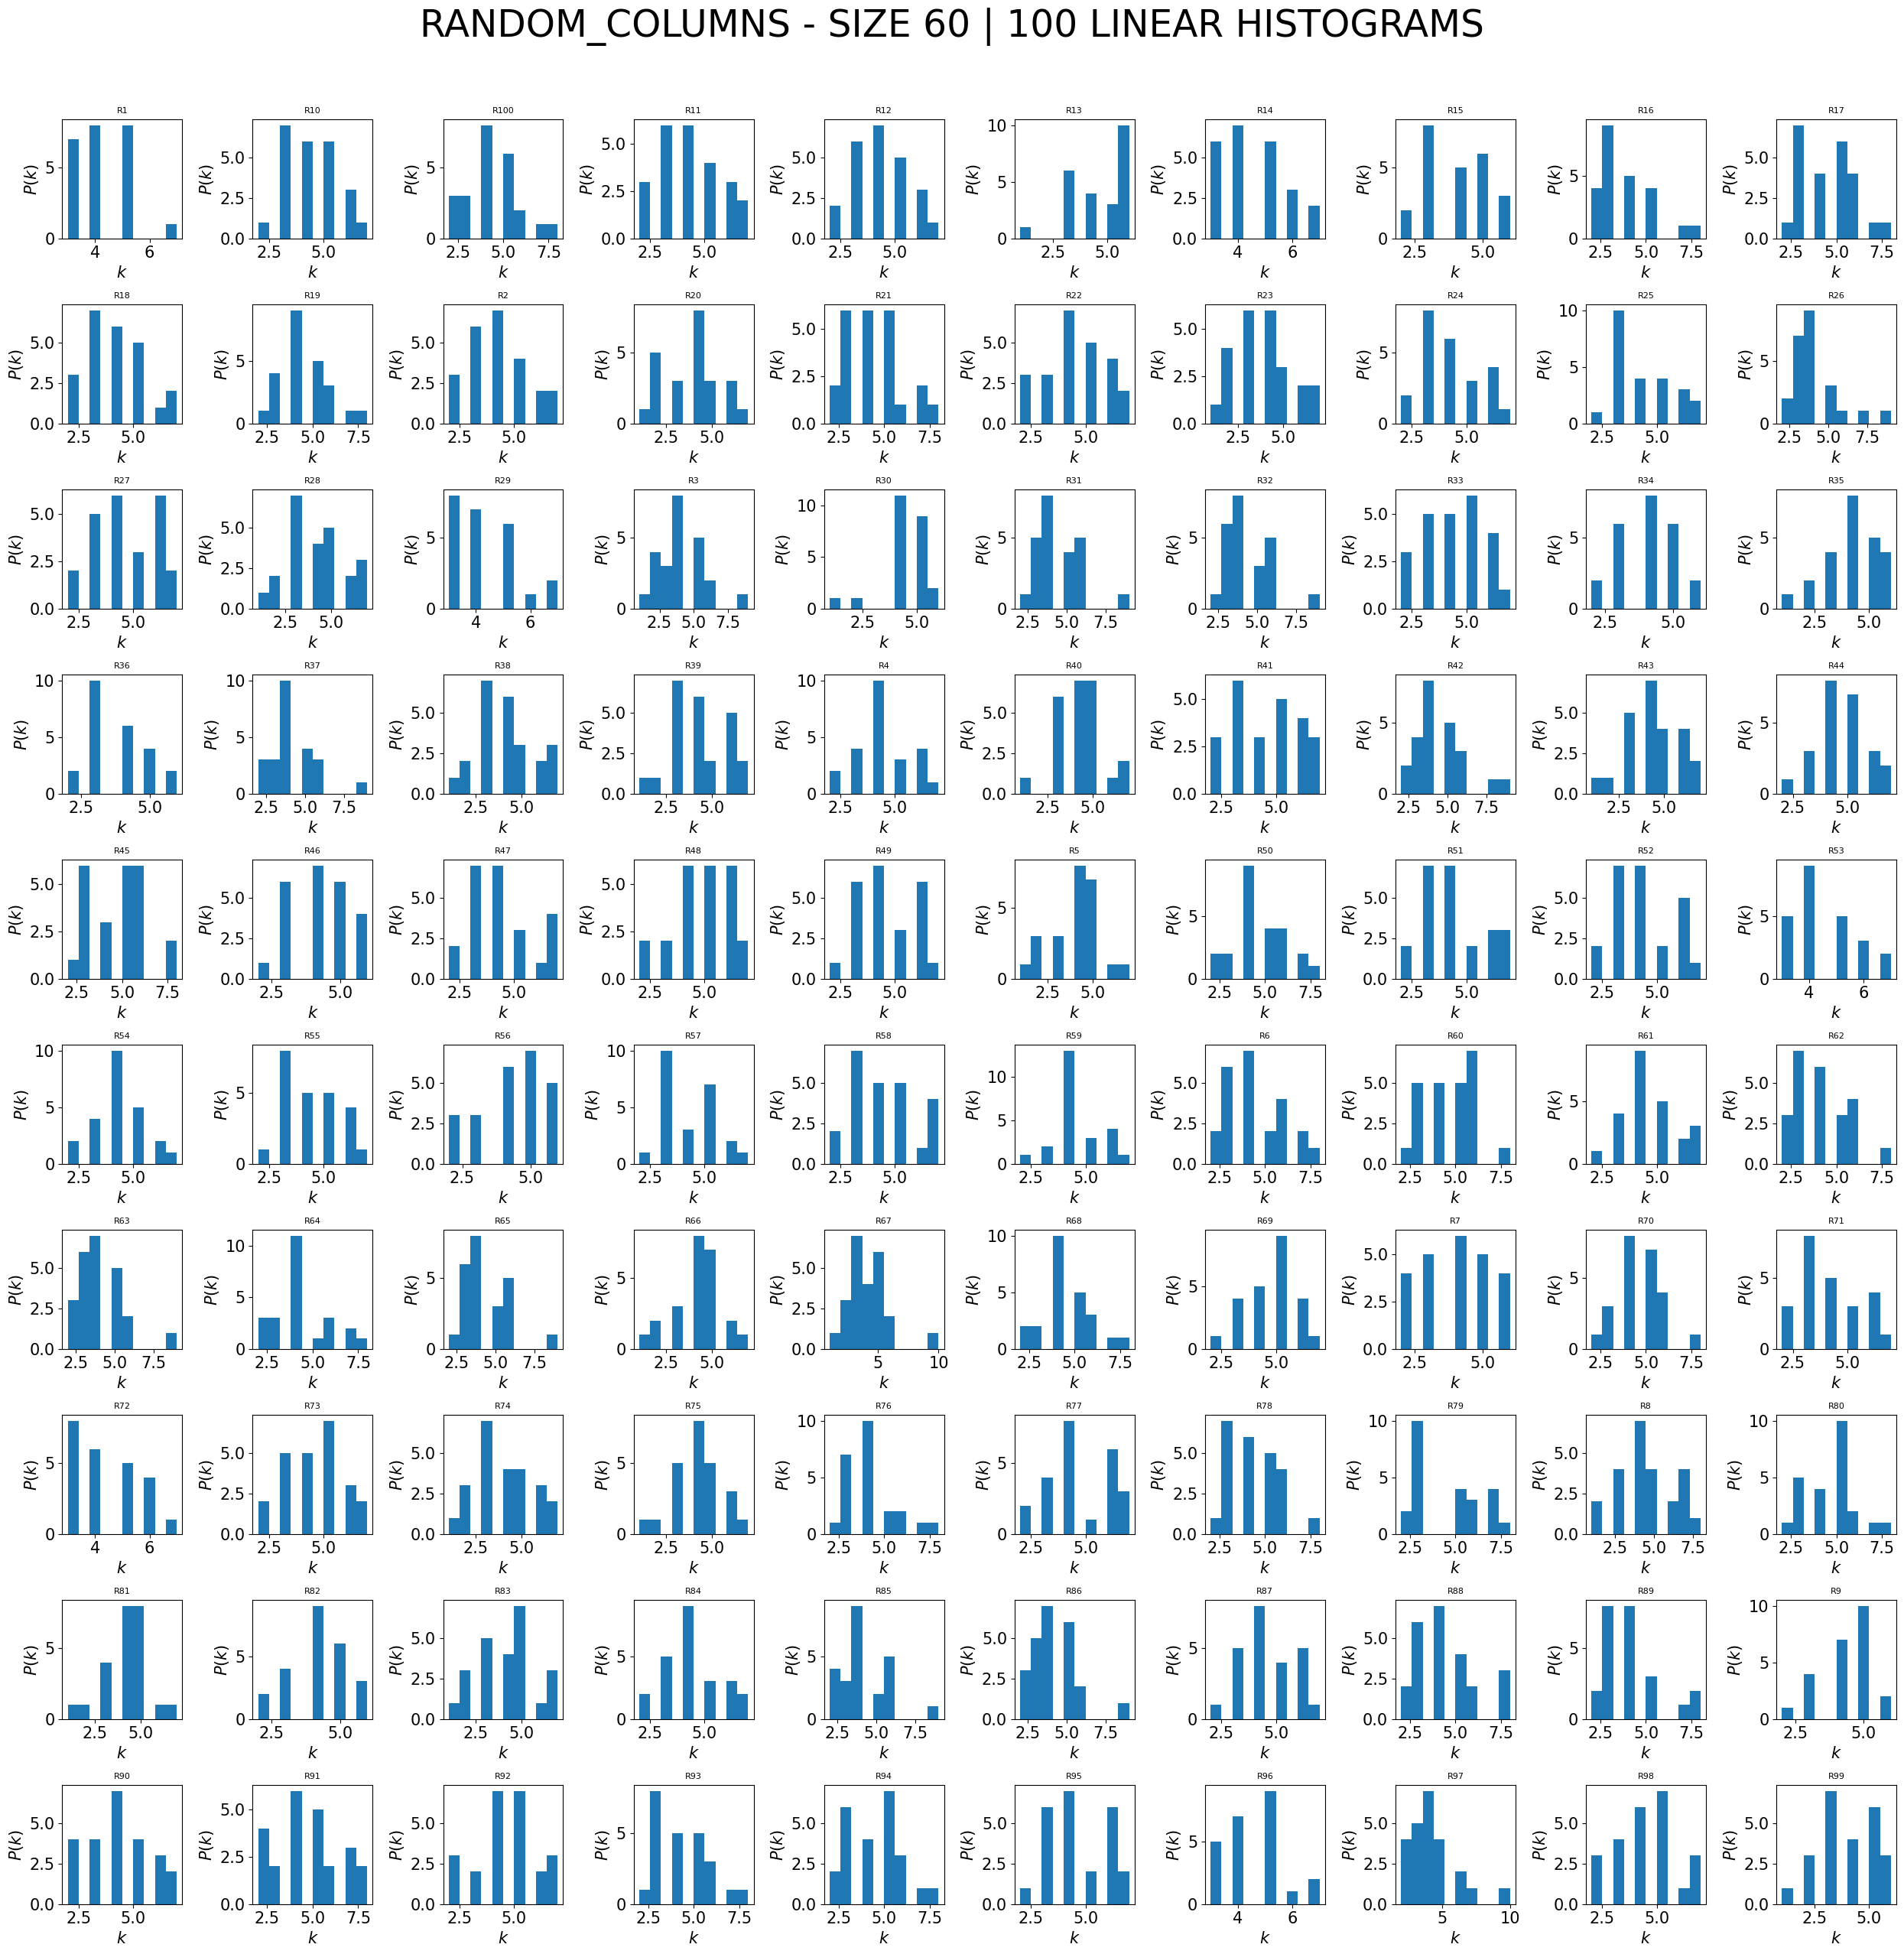

📊 Showing 100 LINEAR plots for Size 90...


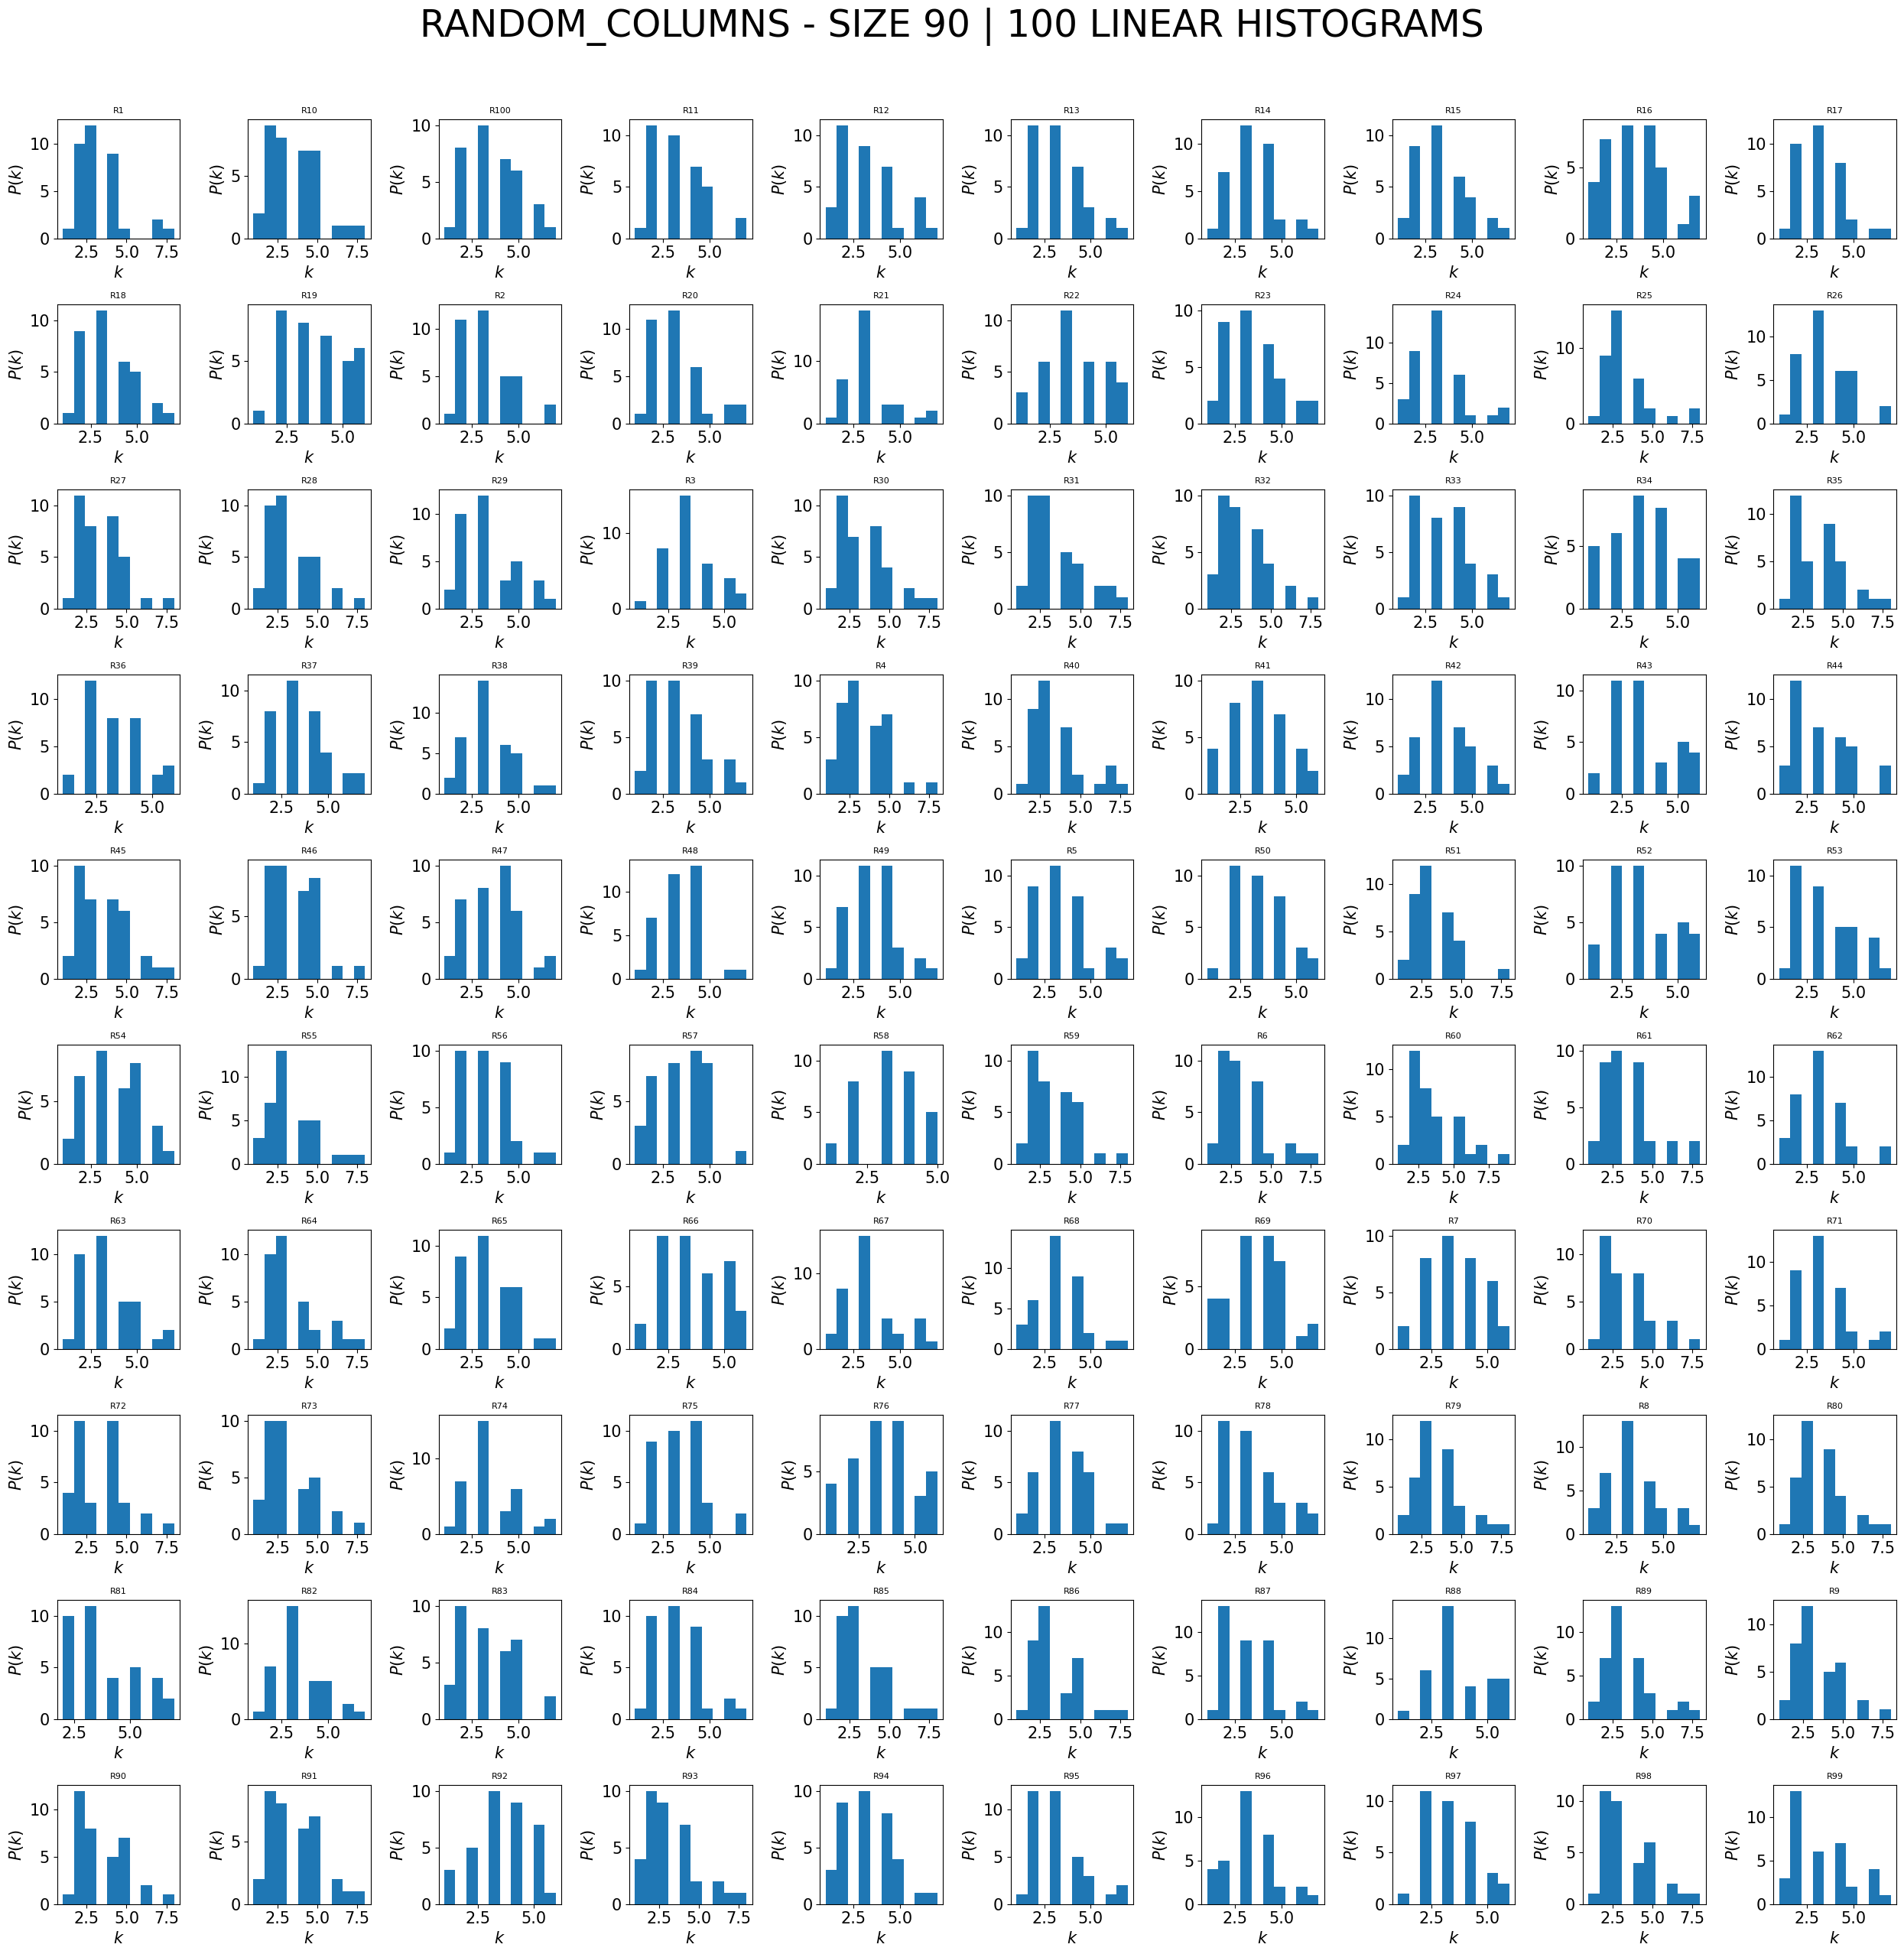

📊 Showing 100 LINEAR plots for Size 90...


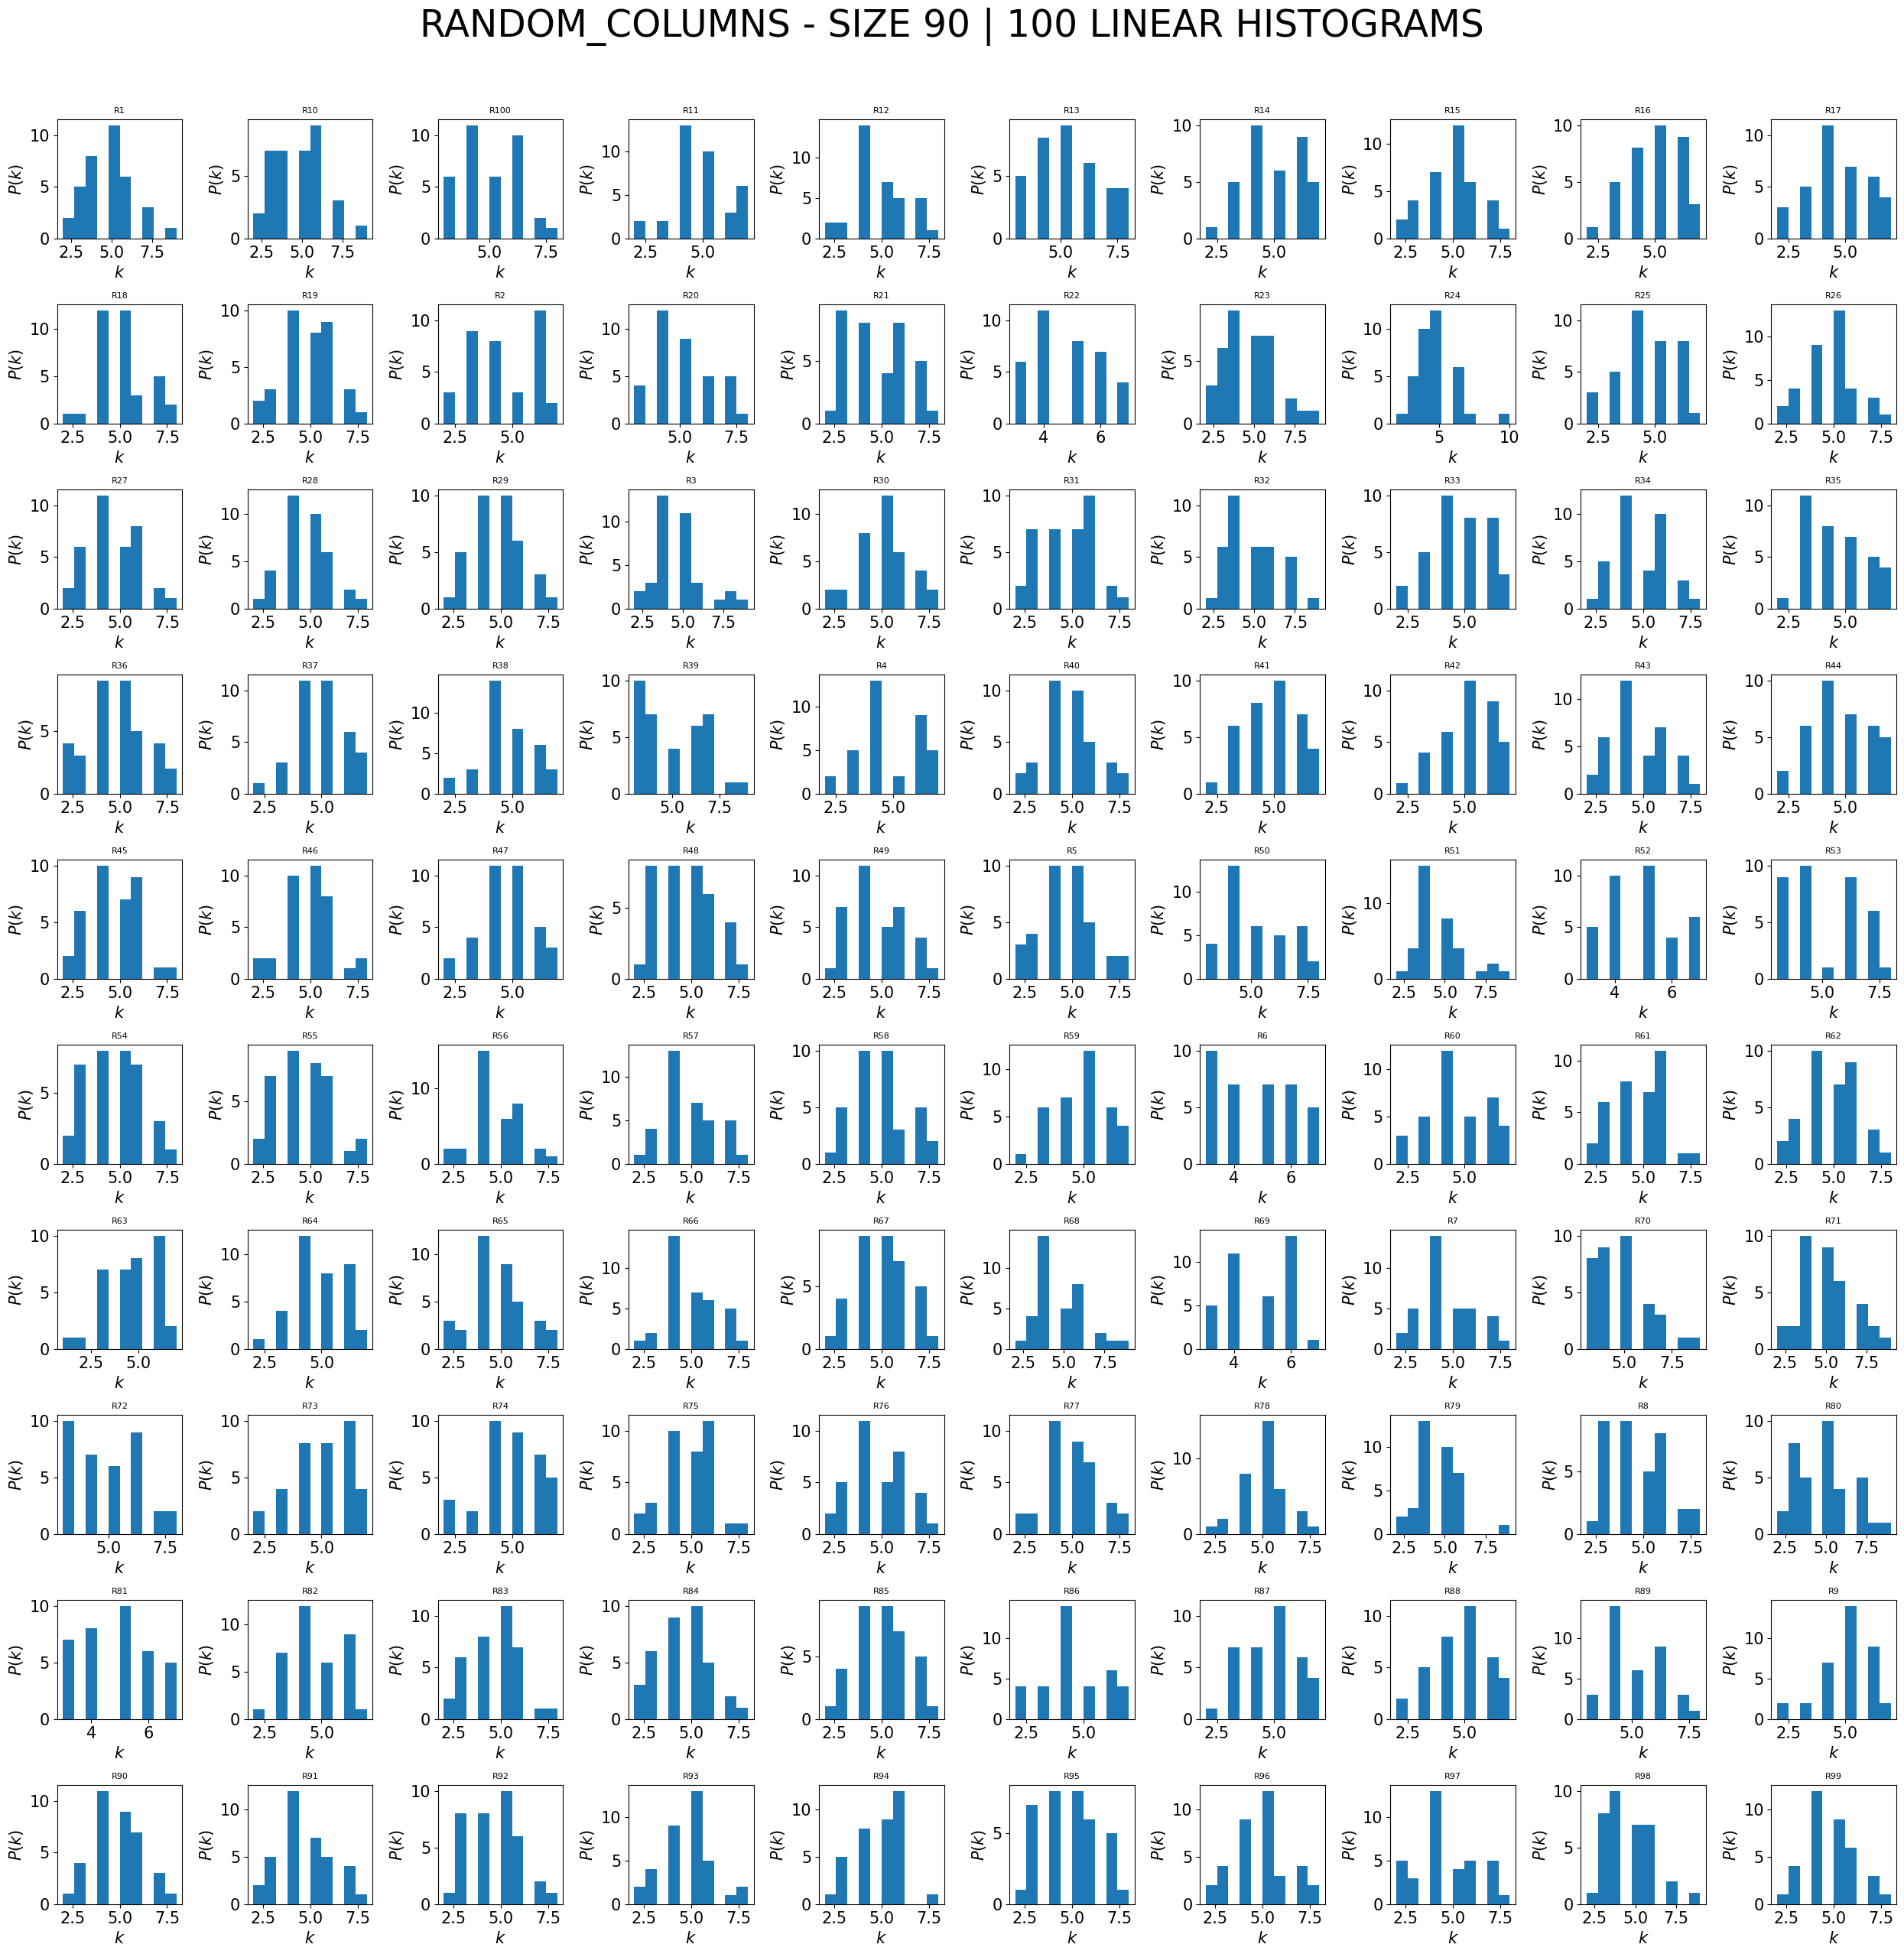

📊 Showing 100 LINEAR plots for Size 30...


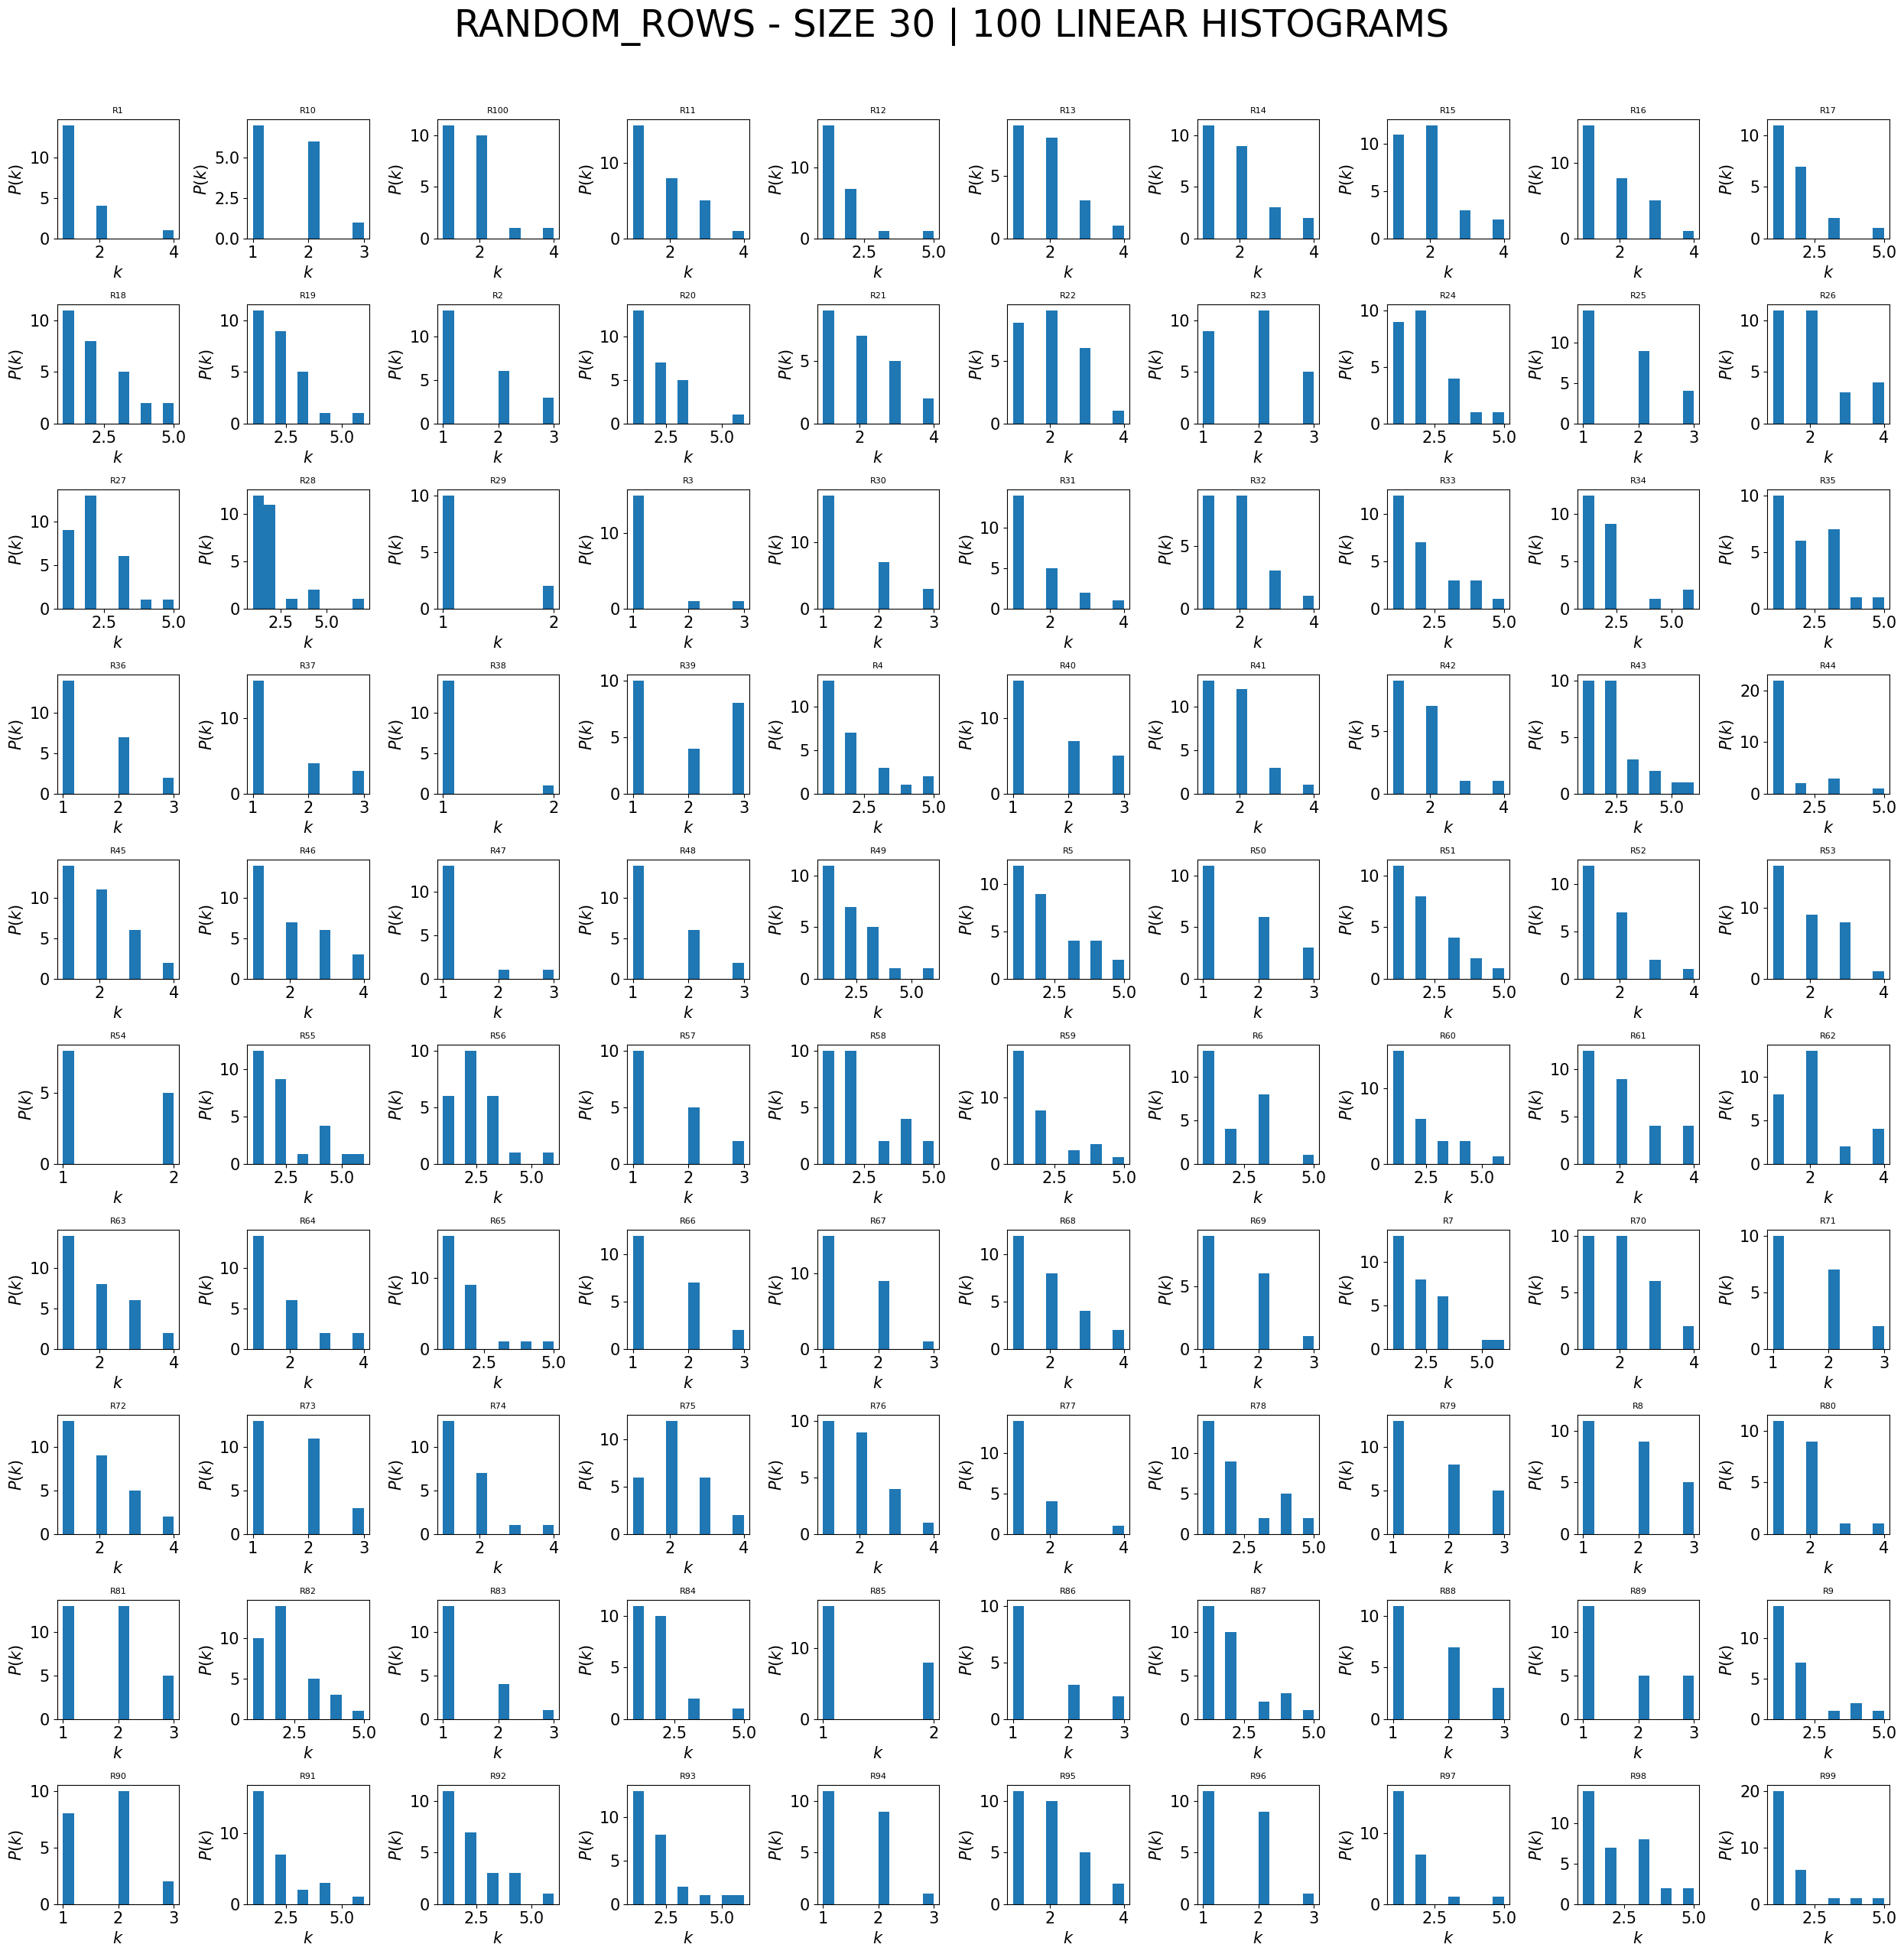

📊 Showing 100 LINEAR plots for Size 30...


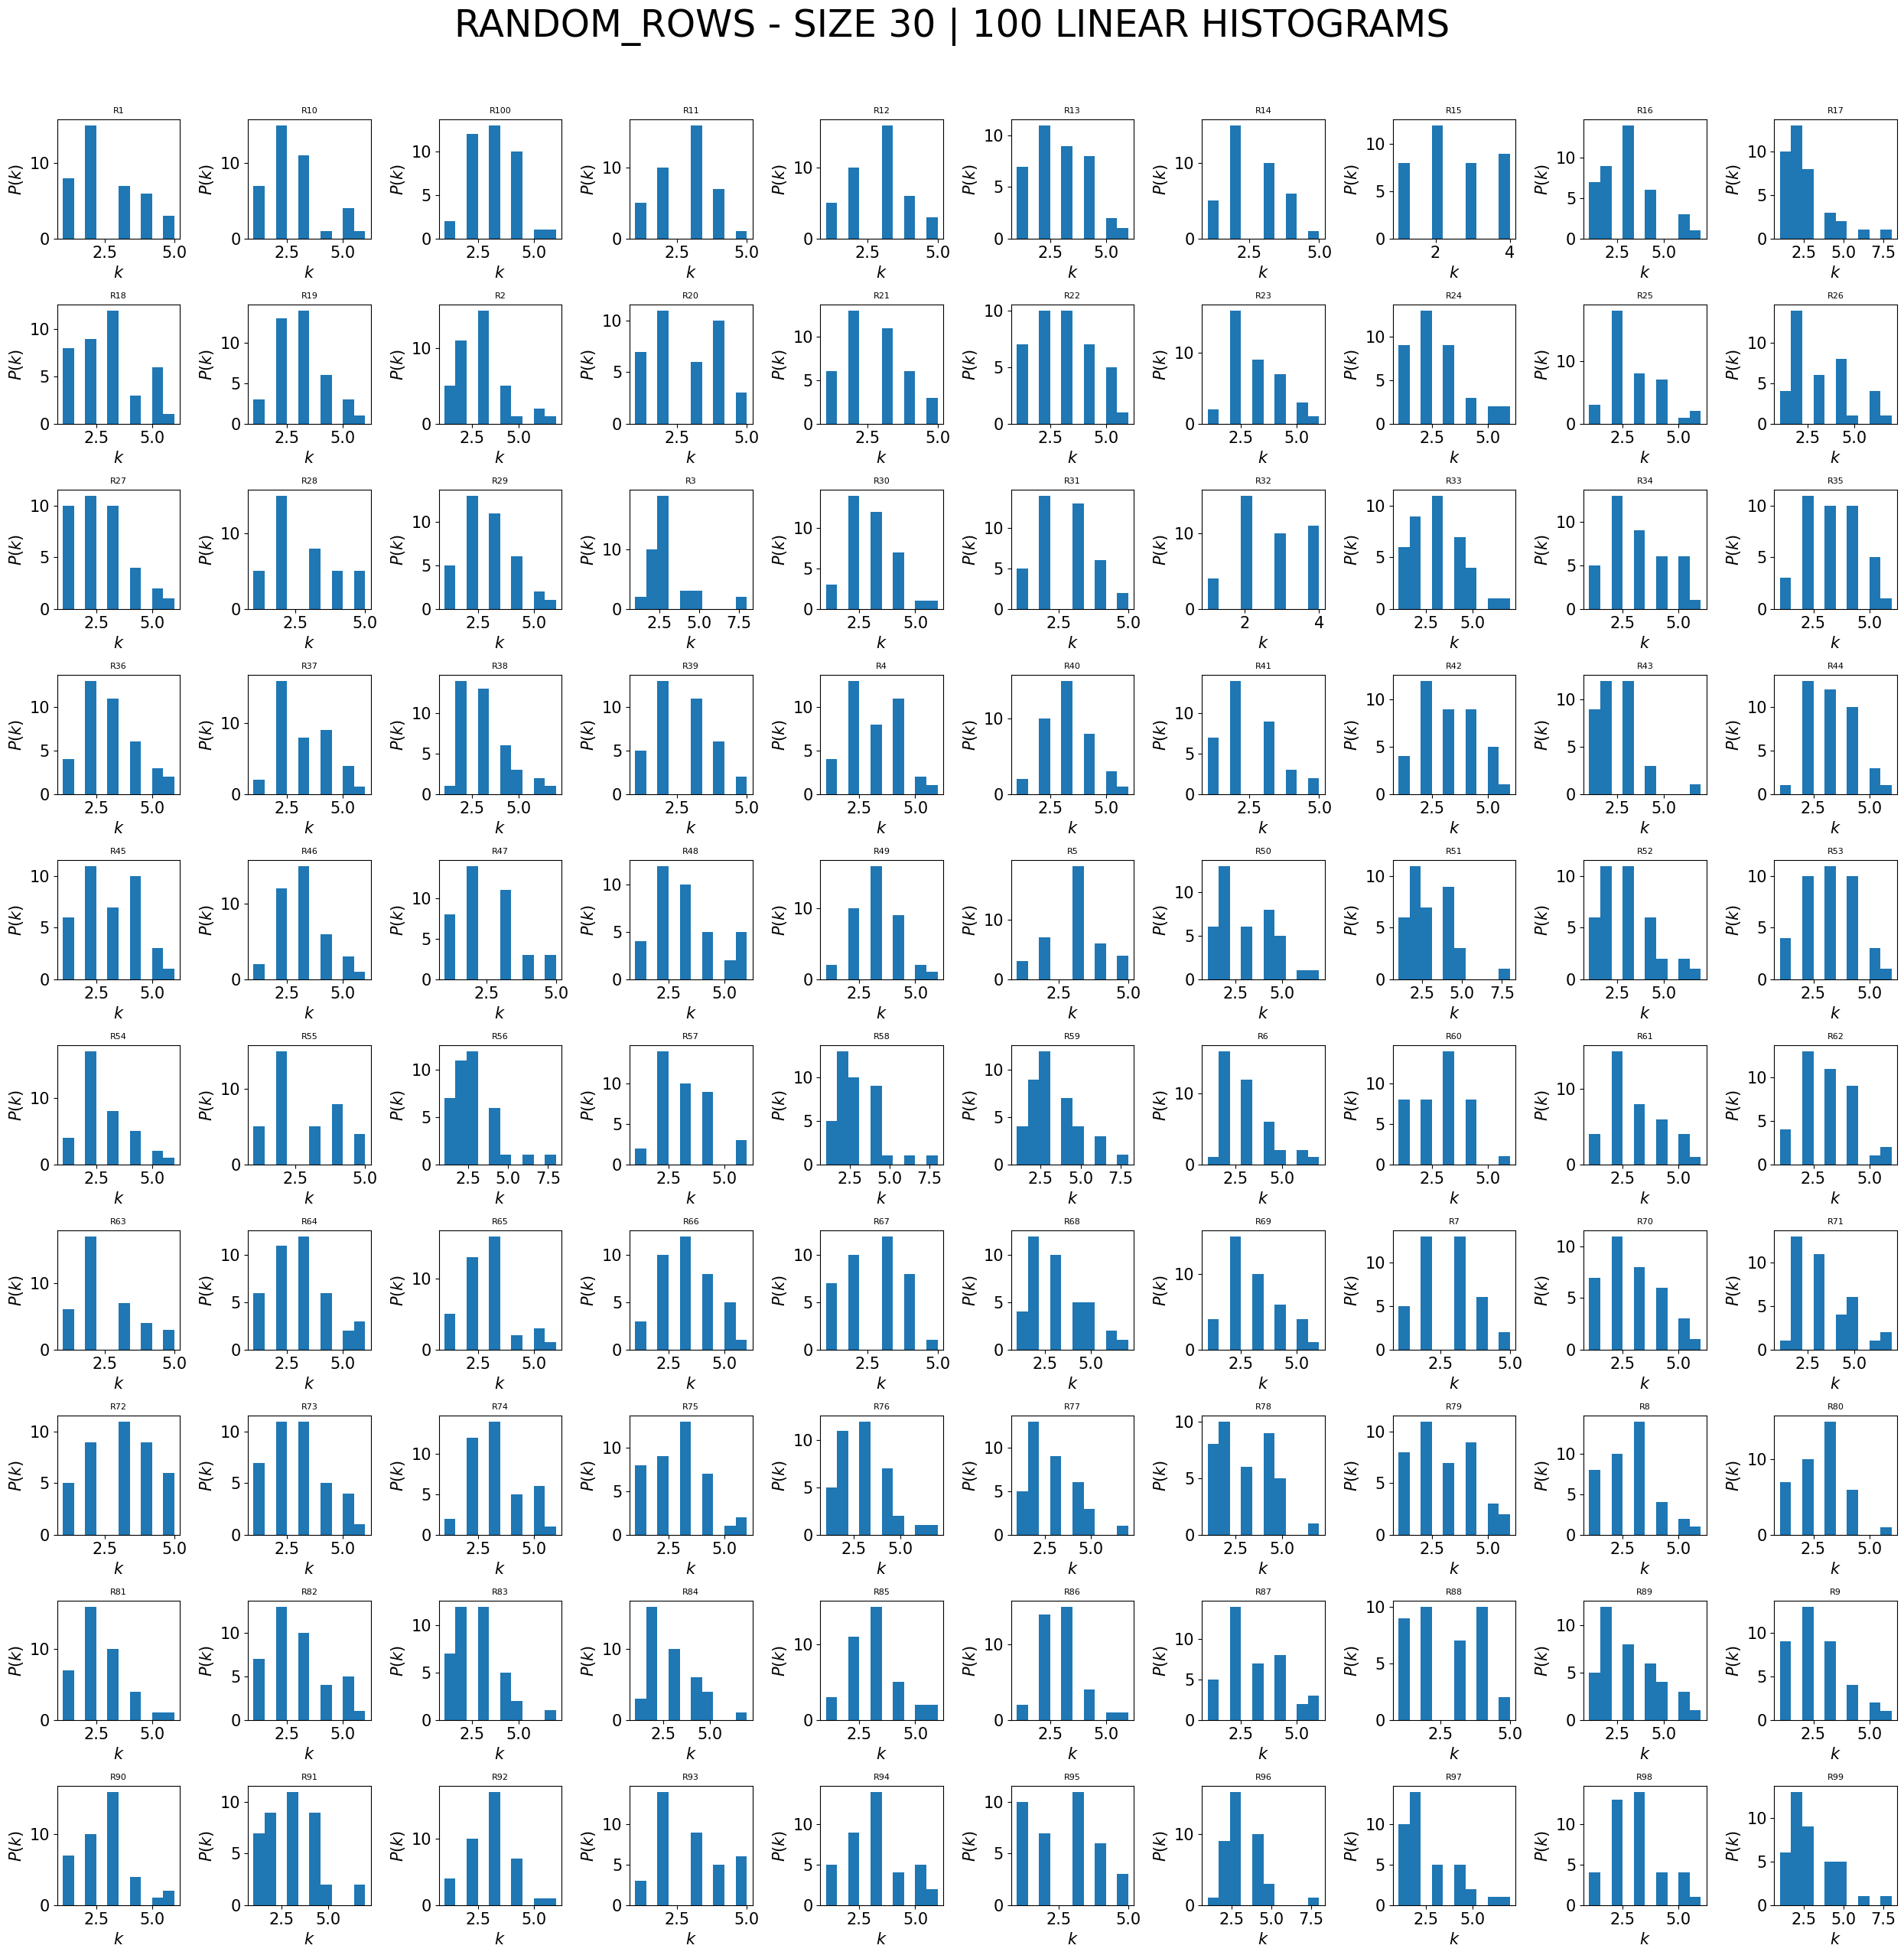

📊 Showing 100 LINEAR plots for Size 60...


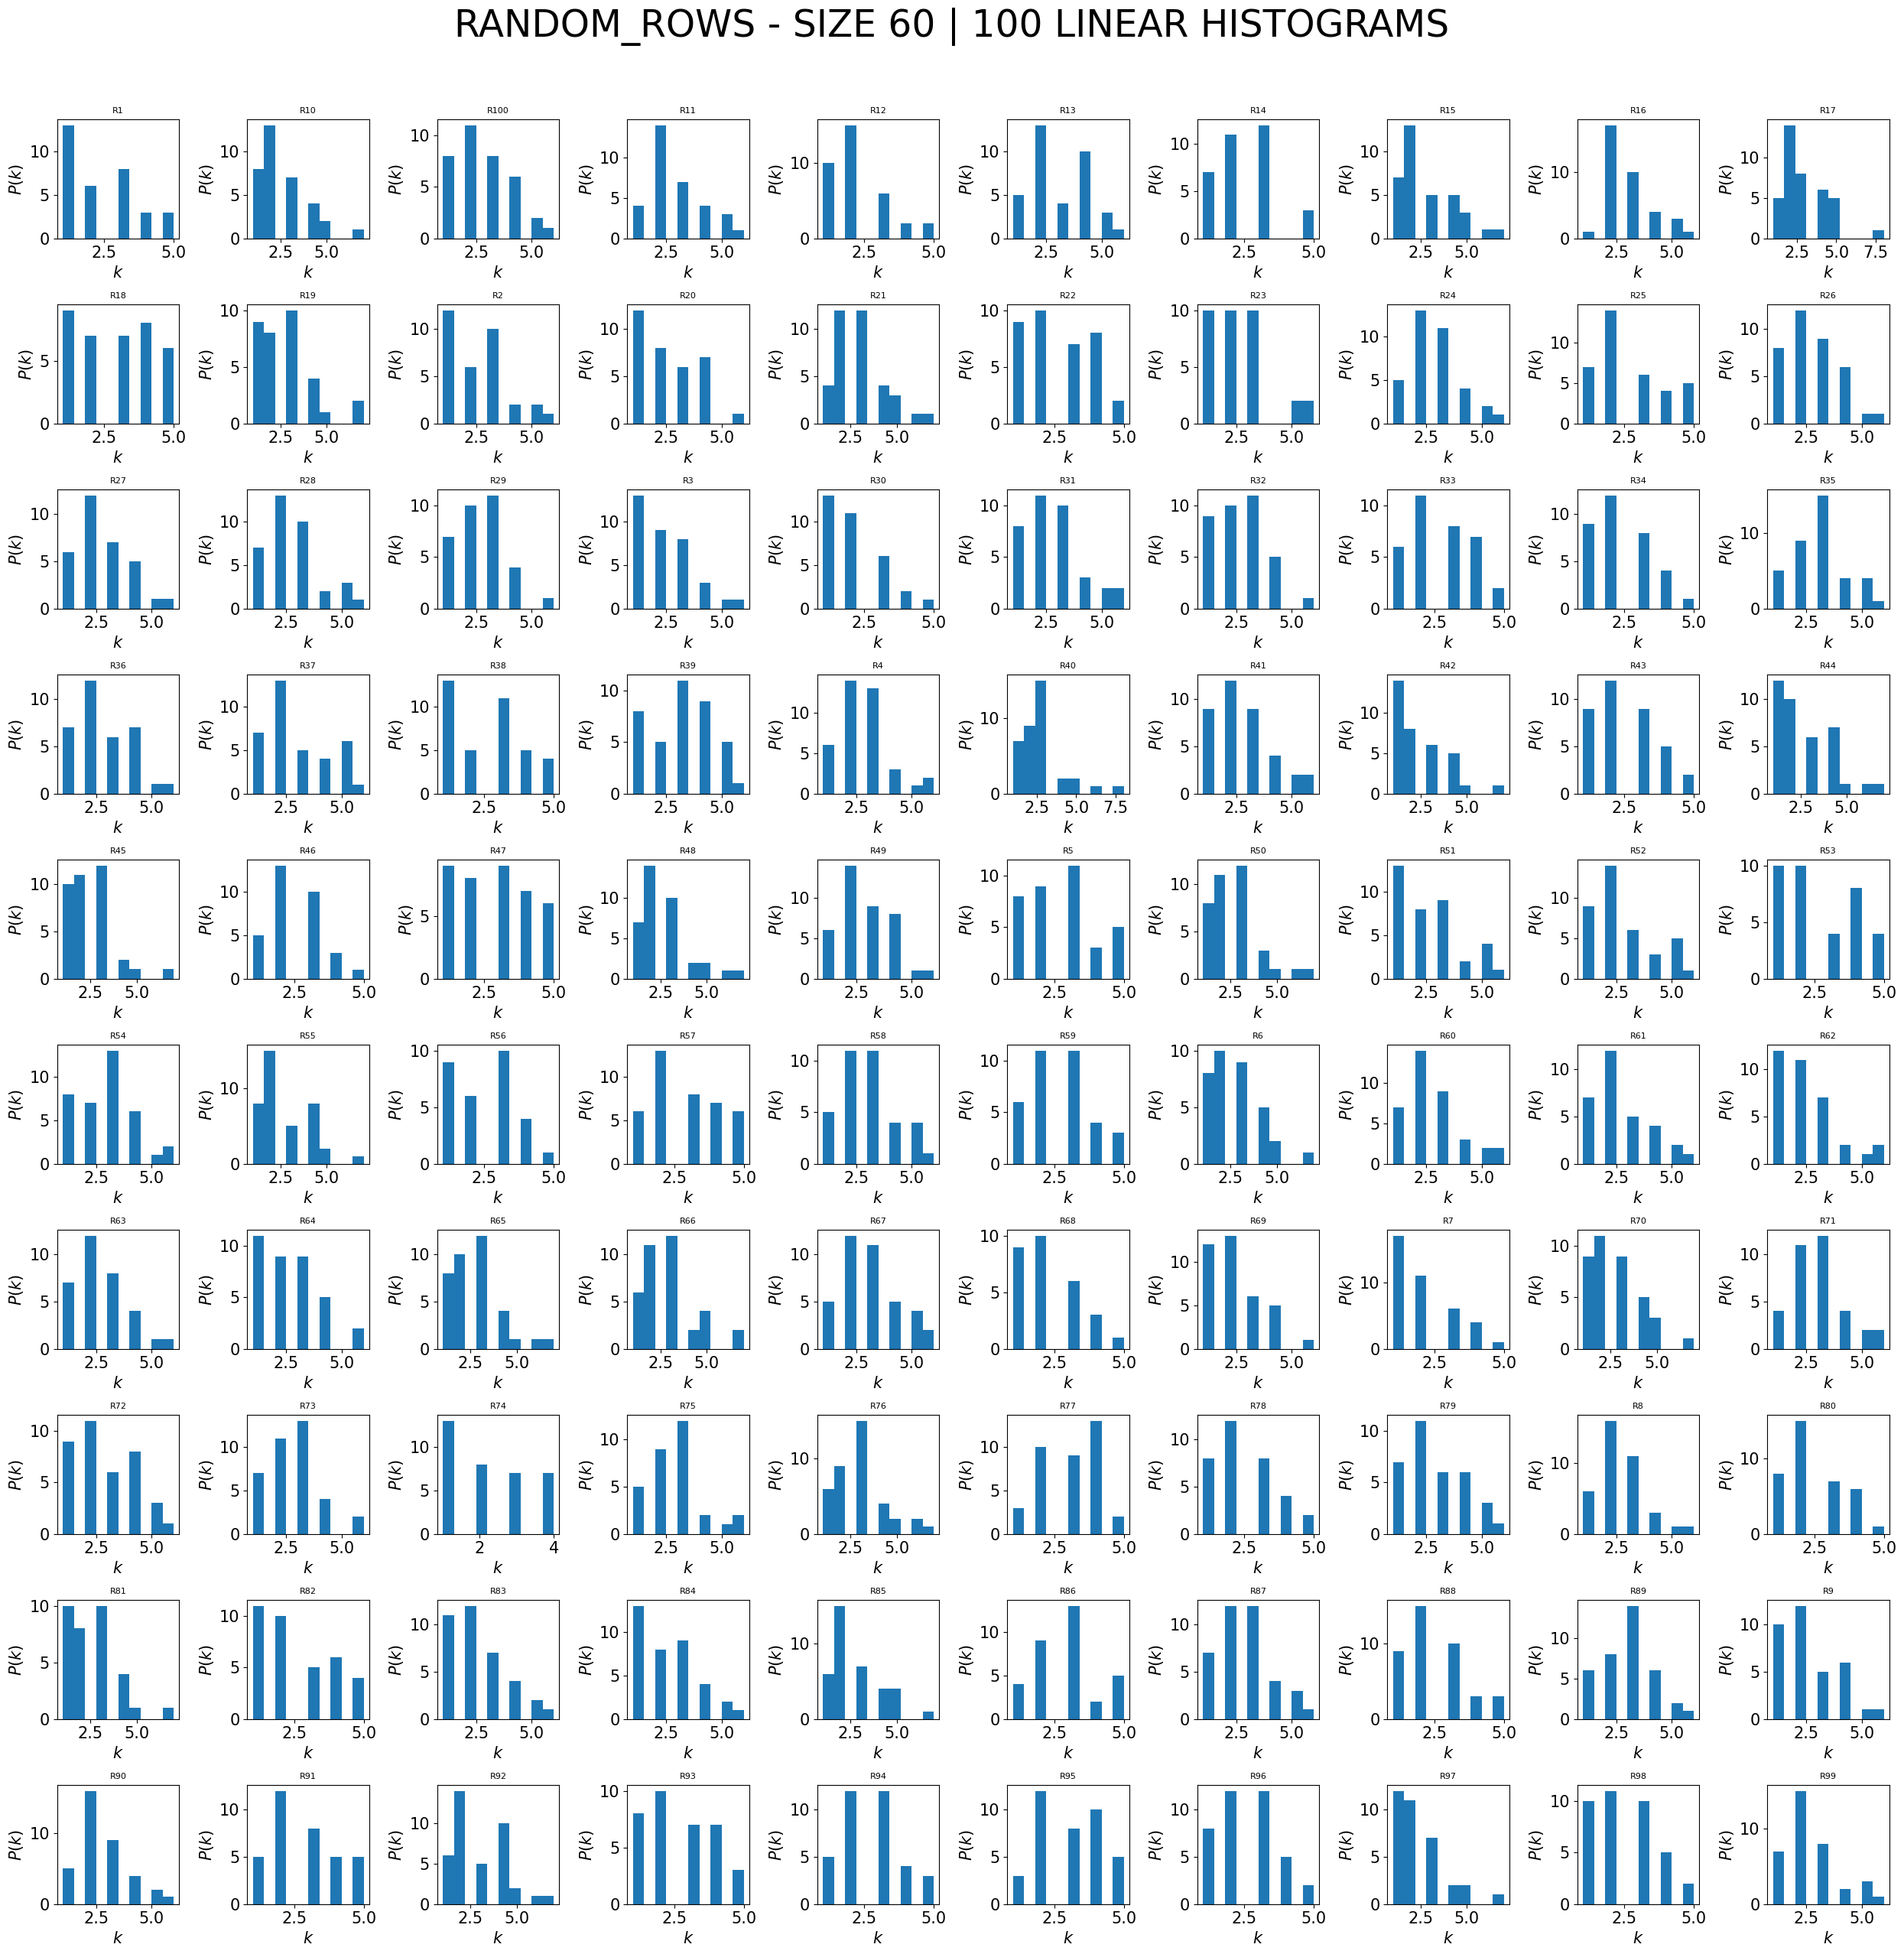

📊 Showing 100 LINEAR plots for Size 60...


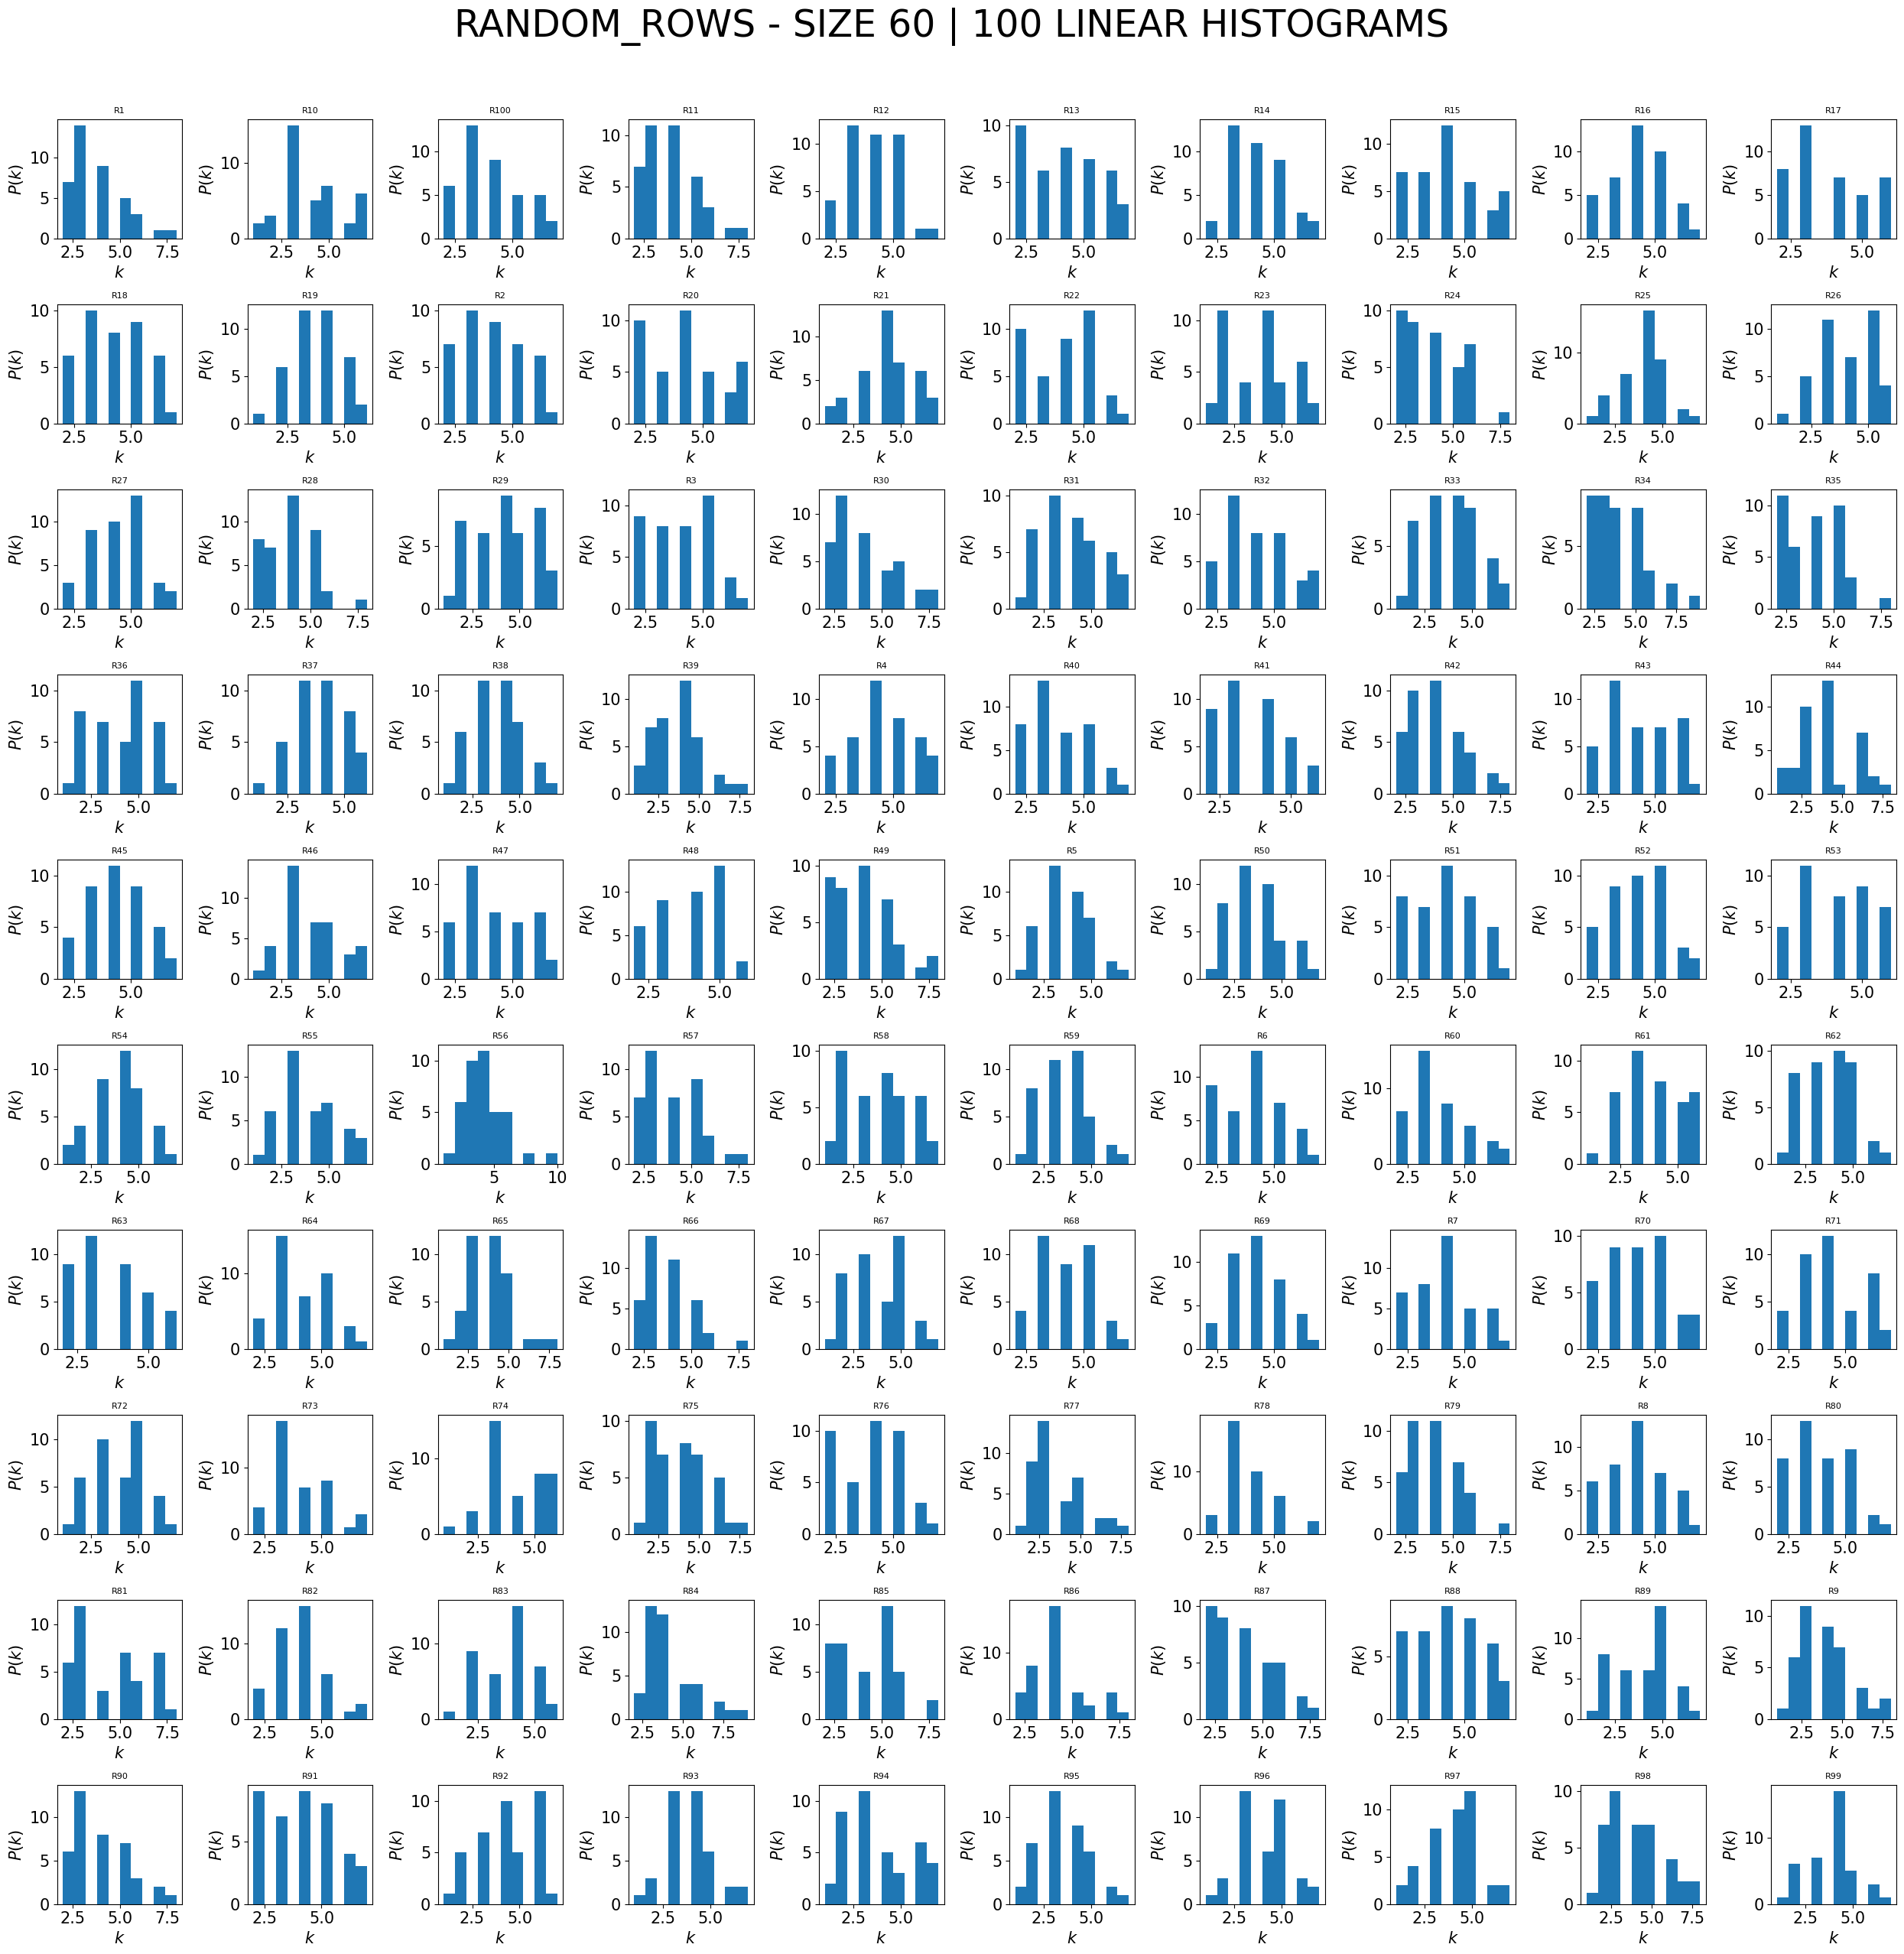

📊 Showing 100 LINEAR plots for Size 90...


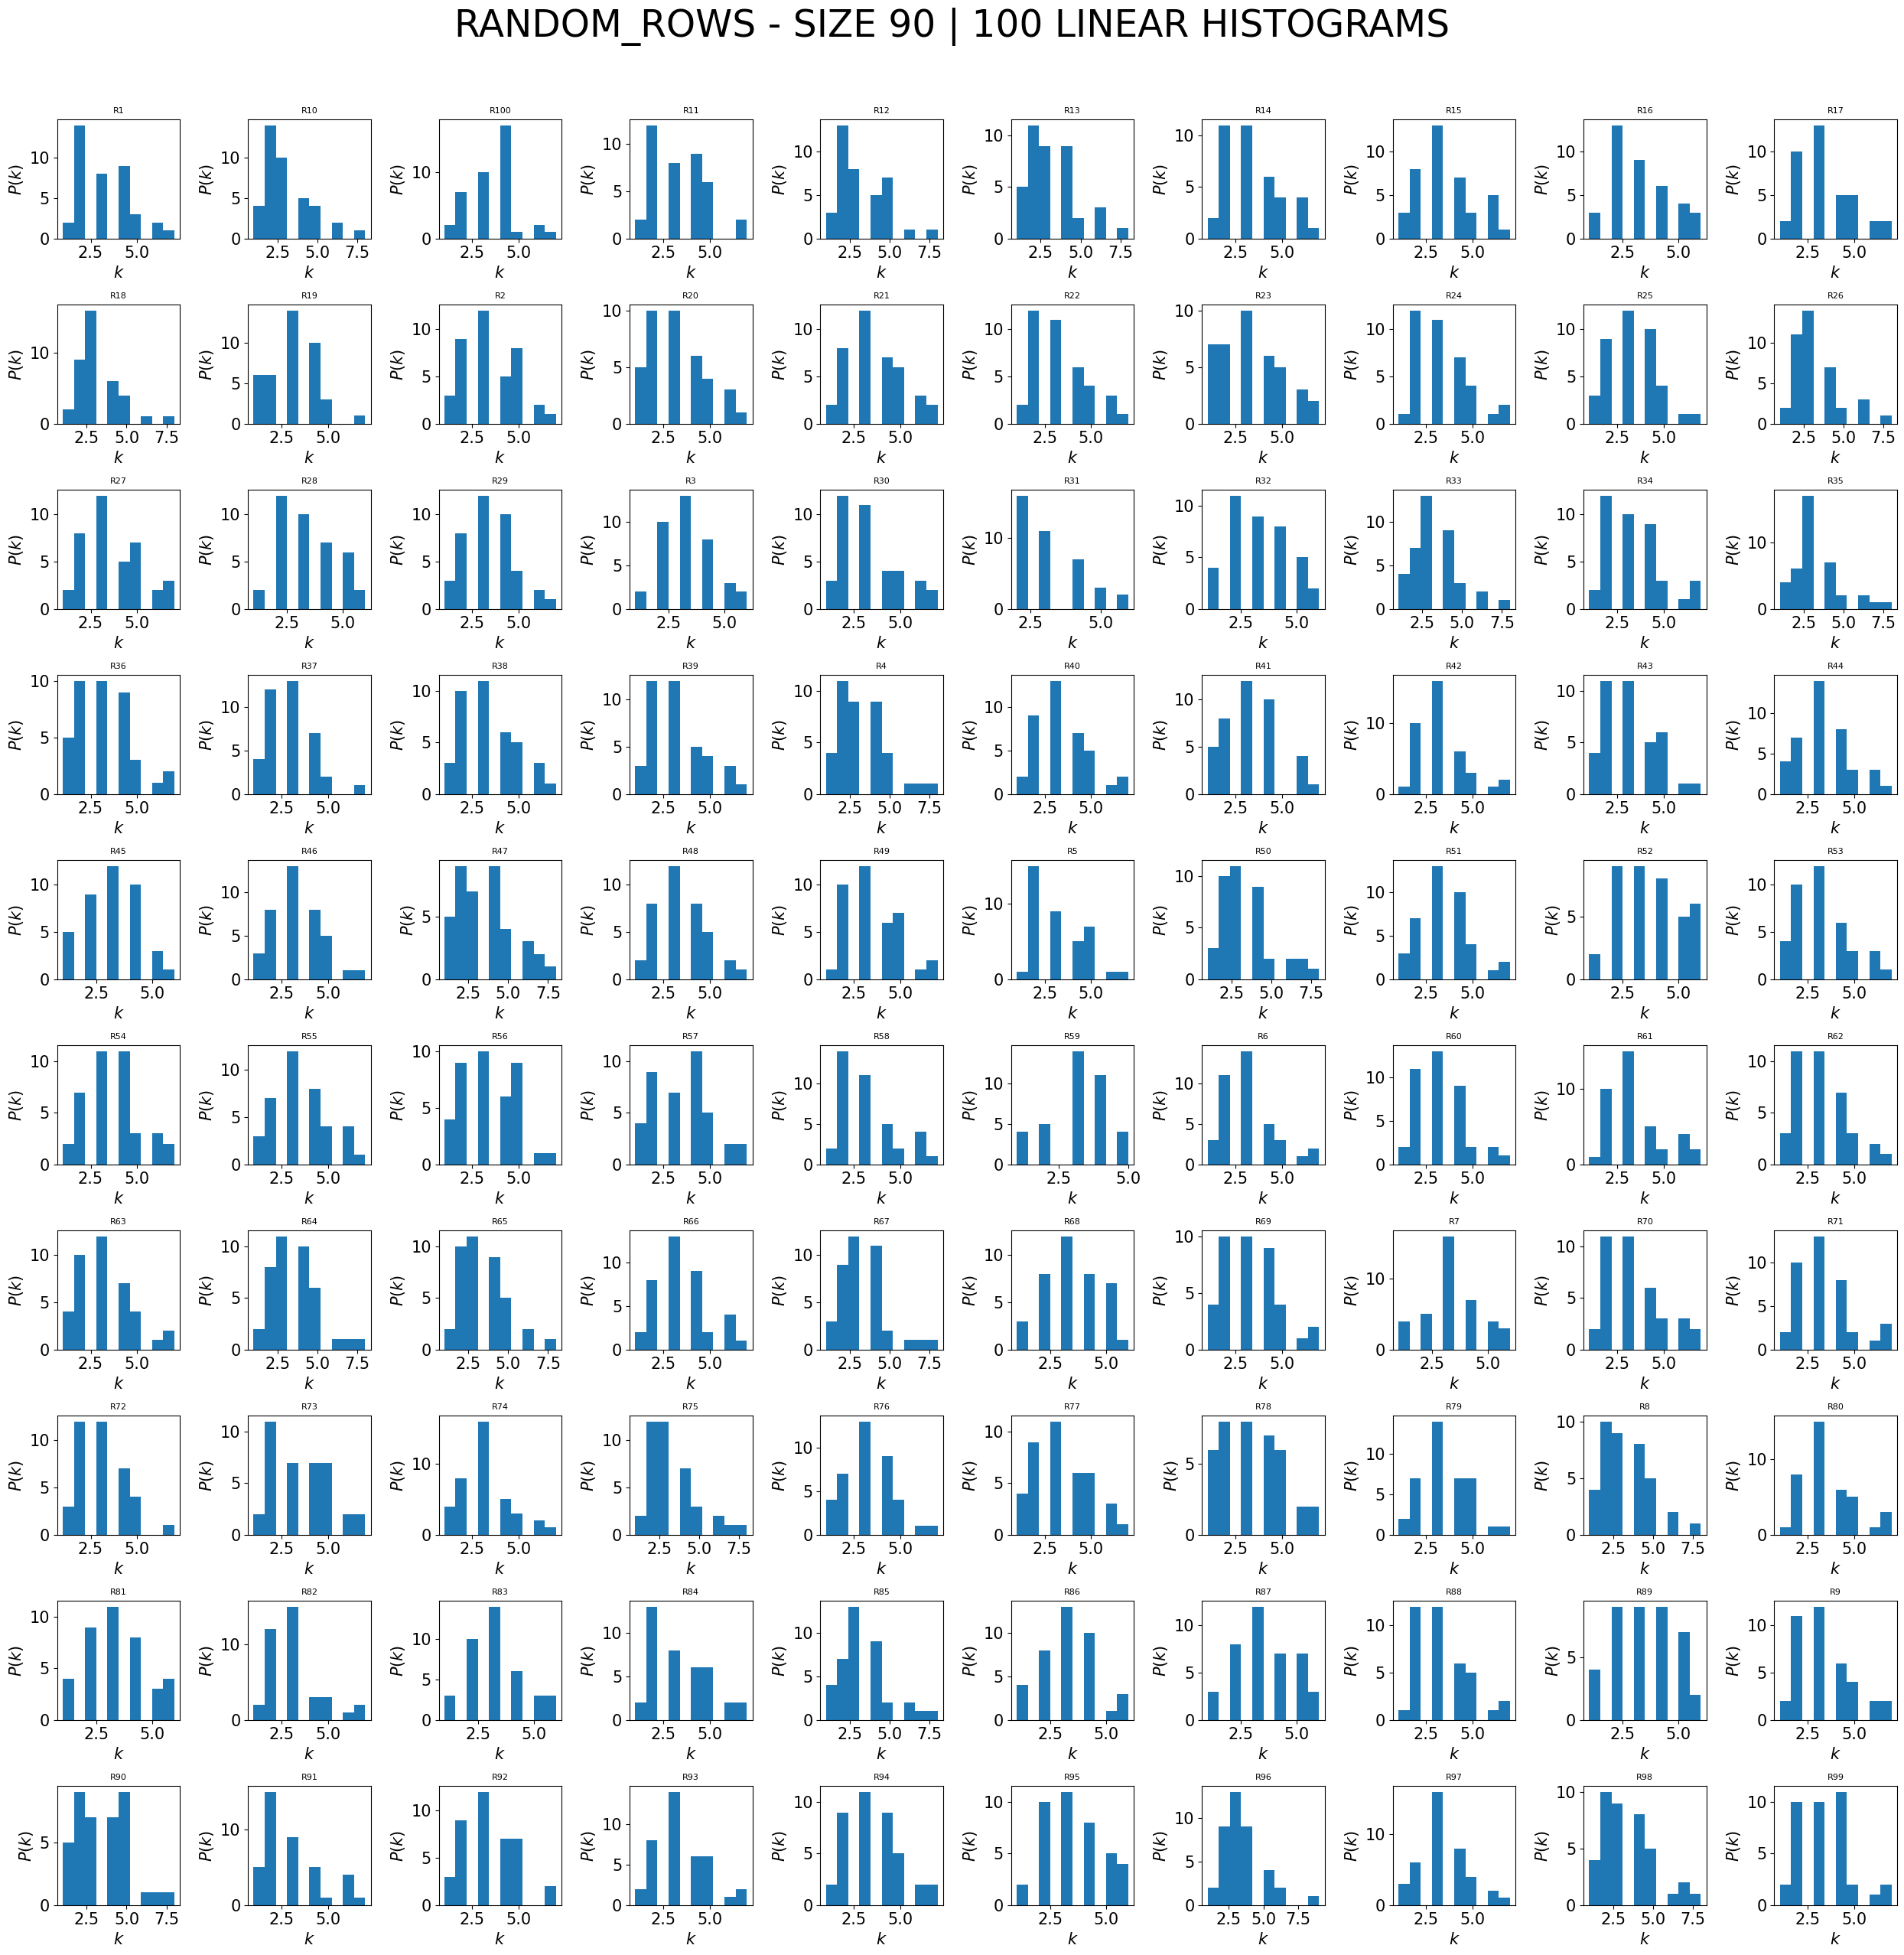

📊 Showing 100 LINEAR plots for Size 90...


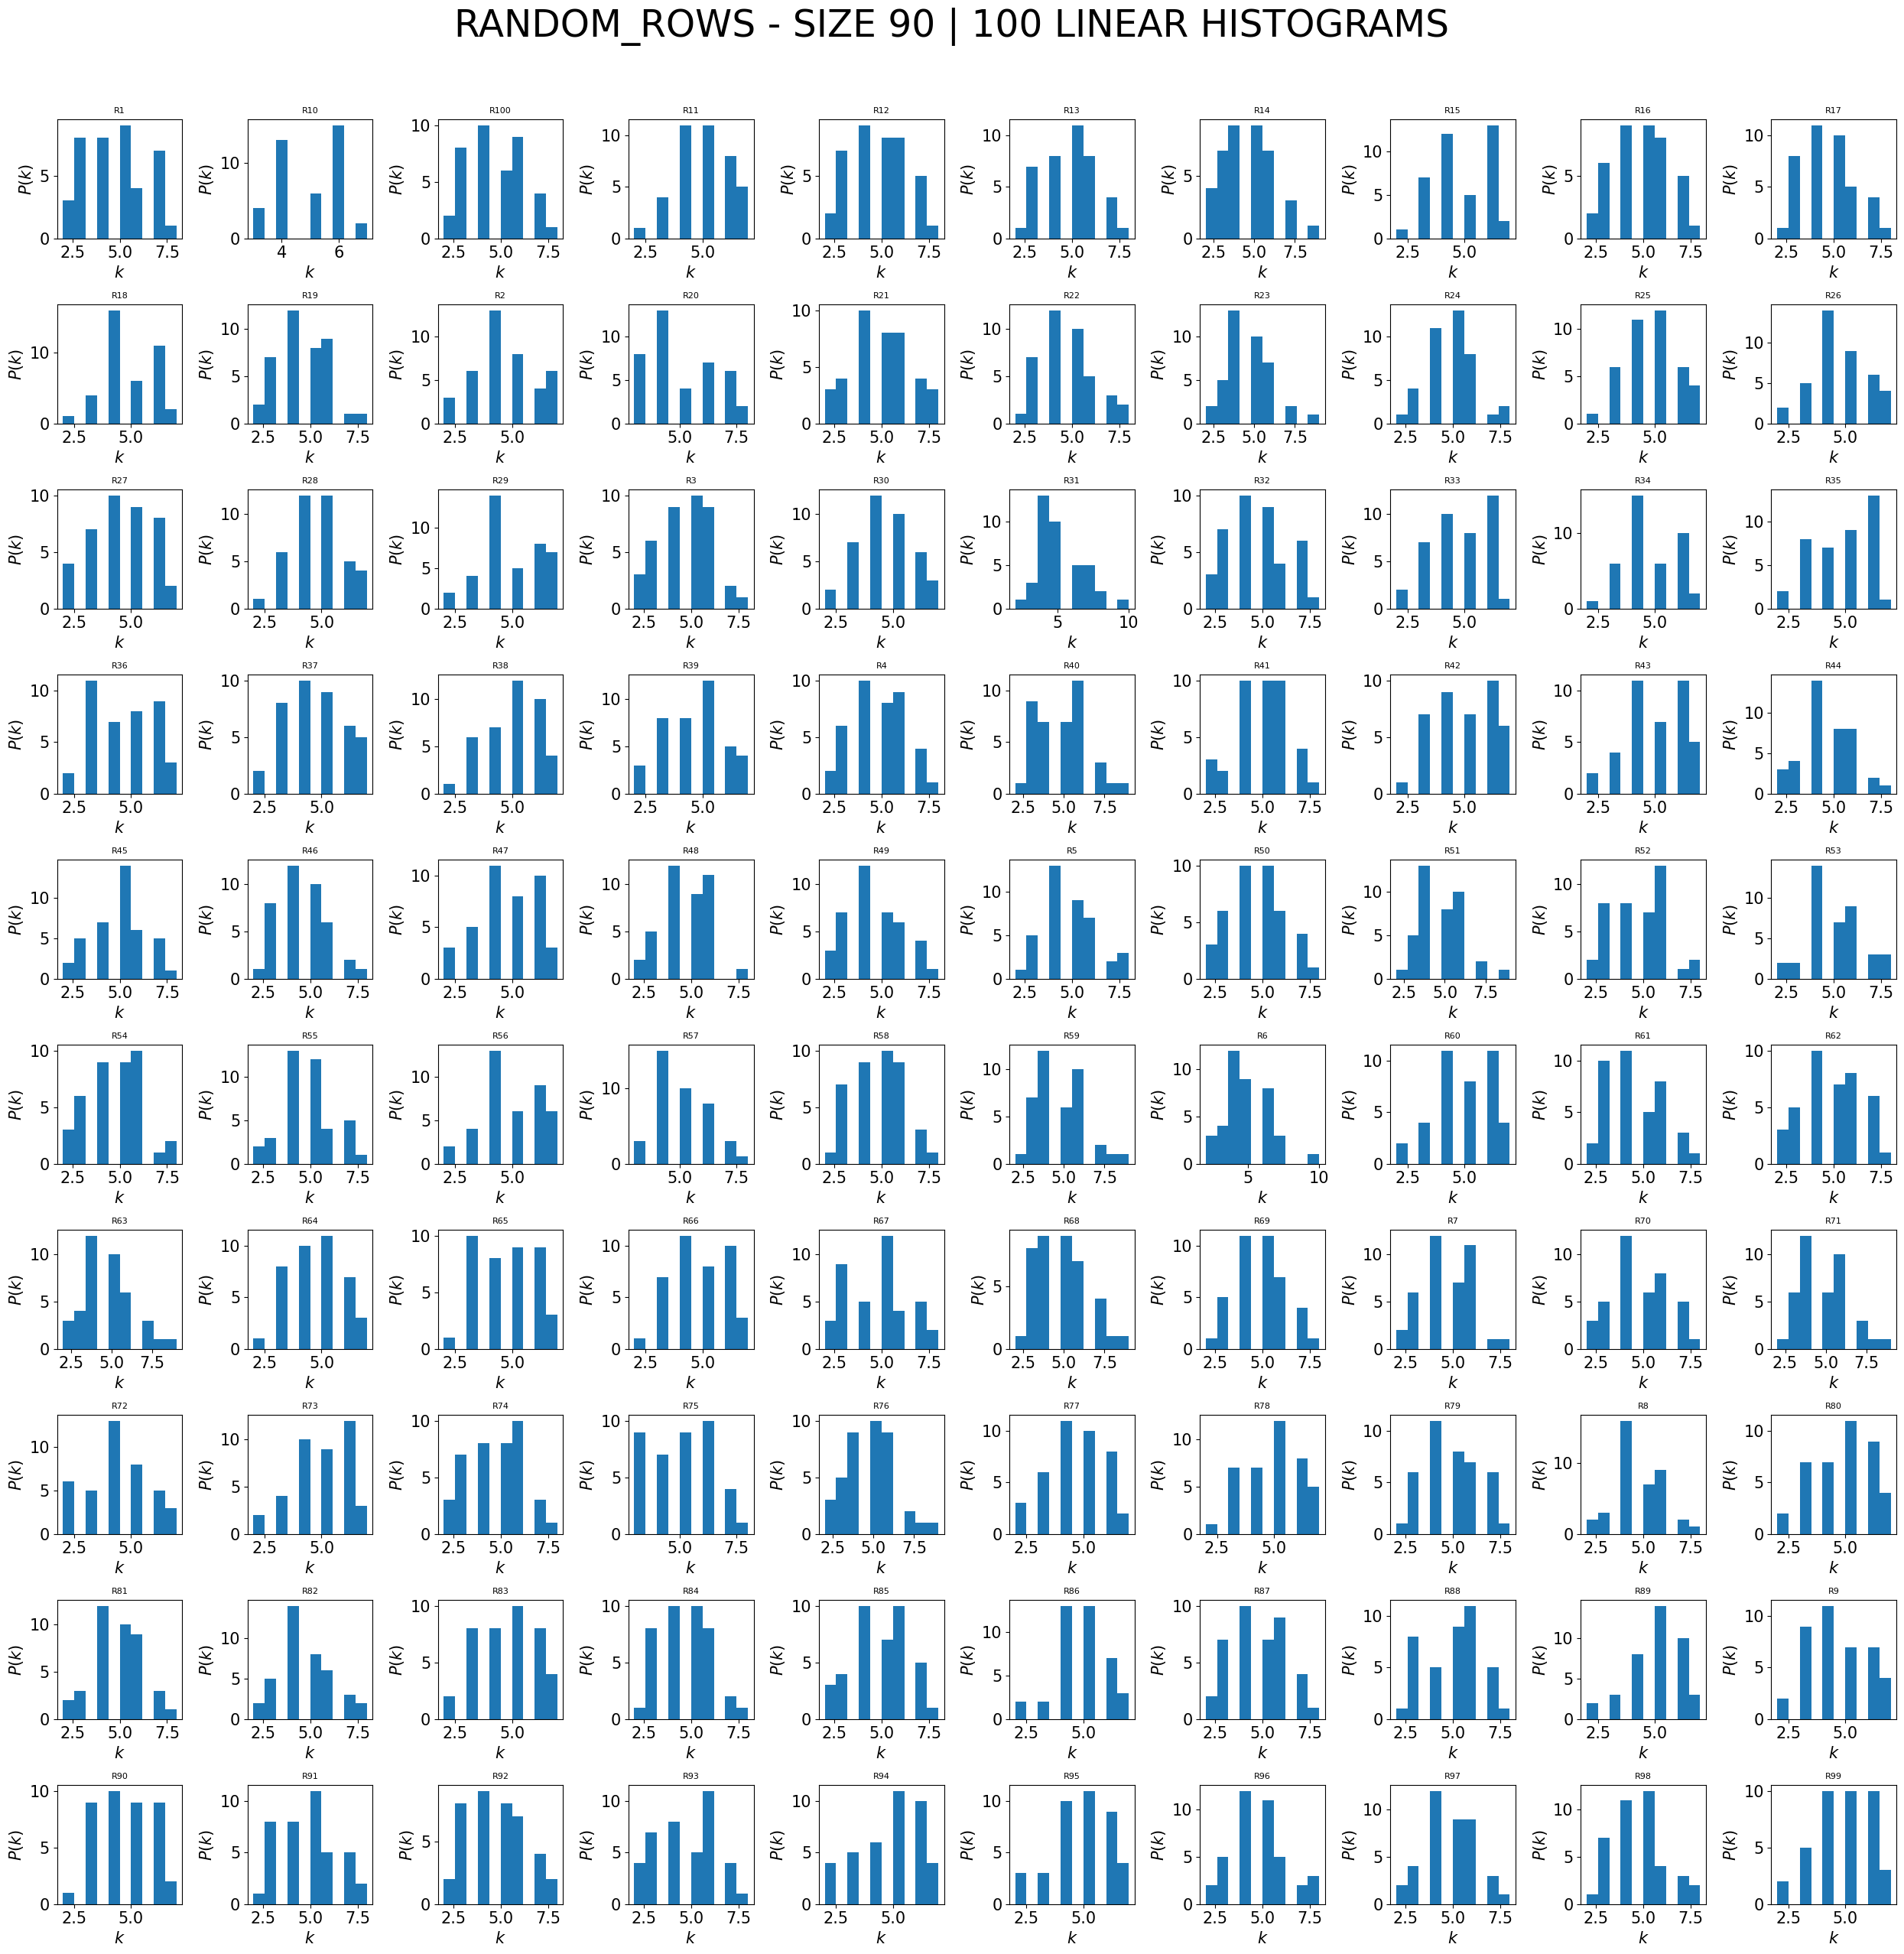

In [3]:

# --- EXECUTION ---
BASE_PATH = "/Volumes/MZ BACKUP/data/flash_weave/iHMP_IBDMDB_2019"
plot_sequential_distributions(BASE_PATH)